In [1]:
# Main Files

# The dataset consists of 4 major CSV files:

# File	Description
# train_transaction.csv	Transaction details + fraud label
# train_identity.csv	Device/browser/user identity info
# test_transaction.csv	Test transactions
# test_identity.csv	Test identity information

# The files are linked using:

# TransactionID
# Important Column Groups

# The dataset has hundreds of columns (400+). Many are anonymized.

# 1. Transaction Information

# These columns describe transaction behavior.

# Column	Meaning
# TransactionID	Unique transaction ID
# TransactionDT	Time delta from a reference point
# TransactionAmt	Transaction amount
# ProductCD	Product/payment category
# card1-card6	Payment card information
# addr1, addr2	Billing region/address
# dist1, dist2	Distance-related features
# P_emaildomain	Purchaser email domain
# R_emaildomain	Recipient email domain
# 2. Target Column
# Column	Meaning
# isFraud	Fraud label (0/1)
# 3. C Columns (Count Features)

# These are anonymized behavioral/count features.

# Examples:

# C1, C2, C3 ... C14

# Possible meanings:

# transaction counts
# card usage frequency
# historical behavior counts

# Actual meanings are hidden.

# 4. D Columns (Time Features)

# Examples:

# D1, D2, D3 ... D15

# These are timing/delay-related features such as:

# days since last transaction
# account age
# inactivity duration
# 5. M Columns (Match Flags)

# Examples:

# M1, M2 ... M9

# These are mostly:

# Yes/No flags
# match indicators
# verification checks
# 6. V Columns (Engineered Anonymous Features)

# Largest feature group:

# V1 → V339

# These are anonymized numerical features generated from:

# PCA-like transformations
# aggregation features
# risk indicators

# Their exact meaning is intentionally hidden.

# Identity Dataset Columns

# The identity files contain device and browser details.

# Important columns:

# Column	Meaning
# DeviceType	mobile / desktop
# DeviceInfo	device/browser string
# id_01 → id_38	anonymized identity features

# Some examples:

# browser version
# operating system
# screen resolution
# fraud risk signals
# Total Number of Columns

# Approximate structure:

# Dataset	Columns
# Transaction file	~394 columns
# Identity file	~41 columns
# Combined	~430+ columns

# Different versions/preprocessed datasets may slightly vary.

# Common Problems in This Dataset

# This dataset is famous because it is challenging.

# 1. Heavy Missing Values

# Many columns contain:

# 70–95% missing values

# Handling missing data is a major task.

# 2. Imbalanced Classes

# Fraud cases are rare:

# only ~3.5%

# Techniques used:

# SMOTE
# undersampling
# class weighting
# focal loss
# 3. High Cardinality

# Columns like:

# email domains
# cards
# device info

# have many unique values.

# 4. Feature Engineering Complexity

# Top Kaggle solutions relied heavily on:

# aggregation features
# time-based features
# frequency encoding
# target encoding

In [2]:
# pip install numpy pandas scipy matplotlib seaborn scikit-learn jupyterlab notebook plotly statsmodels xgboost lightgbm catboost tensorflow torch torchvision torchaudio transformers datasets optuna shap imbalanced-learn yfinance pywavelets openpyxl xlrd

In [3]:
# !python -m pip install seaborn

In [4]:
import pandas as pd 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [5]:
train_txn  = pd.read_csv('../data/raw/train_transaction.csv')
train_id   = pd.read_csv('../data/raw/train_identity.csv')
test_txn   = pd.read_csv('../data/raw/test_transaction.csv')
test_id    = pd.read_csv('../data/raw/test_identity.csv')

# Merge on TransactionID  left join keeps all transactions
train = train_txn.merge(train_id, on='TransactionID', how='left')
test  = test_txn.merge(test_id,  on='TransactionID', how='left')

In [6]:
train.shape

(590540, 434)

In [7]:
test.shape

(506691, 433)

In [8]:
print(f"Train shape : {train.shape}")    

# Memory audit 
print(f"\nTrain memory: {train.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Column type breakdown
print("\nDtype distribution:")
print(train.dtypes.value_counts())

# Quick scan of column groups (V1–V339 are Vesta features)
cols = {
    'V features'     : [c for c in train.columns if c.startswith('V')],
    'C features'     : [c for c in train.columns if c.startswith('C')],
    'D features'     : [c for c in train.columns if c.startswith('D')],
    'M features'     : [c for c in train.columns if c.startswith('M')],
    'id features'    : [c for c in train.columns if c.startswith('id')],
    'card features'  : [c for c in train.columns if c.startswith('card')],
    'other features': [c for c in train.columns if not c.startswith(('card','V', 'C', 'D', 'M', 'id'))],
}
total=0
for name, lst in cols.items():
    print(f"  {name:16s}: {len(lst)} columns")

print(cols['other features'])

Train shape : (590540, 434)

Train memory: 2080.6 MB

Dtype distribution:
float64    399
str         31
int64        4
Name: count, dtype: int64
  V features      : 339 columns
  C features      : 14 columns
  D features      : 17 columns
  M features      : 9 columns
  id features     : 38 columns
  card features   : 6 columns
  other features  : 11 columns
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain']


In [9]:
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == object:
            if df[col].nunique() / len(df[col]) < 0.5:
                df[col] = df[col].astype('category')

        elif col_type == bool:
            df[col] = df[col].astype(np.int8)

        elif pd.api.types.is_integer_dtype(col_type):
            # Skip if column has nulls — int types can't hold NaN
            if df[col].isnull().any():
                continue
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)

        elif pd.api.types.is_float_dtype(col_type):
            finite_vals = df[col].dropna()
            finite_vals = finite_vals[np.isfinite(finite_vals)]
            if finite_vals.empty:
                continue
            c_min = float(finite_vals.min())
            c_max = float(finite_vals.max())
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory: {start_mem:.1f} MB → {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}% reduction)")
    return df

train = reduce_mem_usage(train)
test  = reduce_mem_usage(test)

Memory: 1984.2 MB → 1073.5 MB (45.9% reduction)
Memory: 1700.3 MB → 922.3 MB (45.8% reduction)


# 1. Target variable analysis

In [10]:
train['isFraud'].isnull().sum()

np.int64(0)

Fraud rate: 3.4990%
Imbalance ratio: 1:28
isFraud
0    569877
1     20663
Name: count, dtype: int64


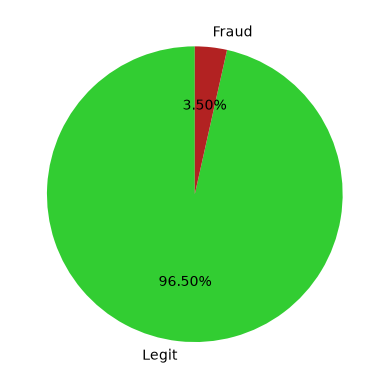

In [11]:
fraud_rate = train['isFraud'].mean()
print(f"Fraud rate: {fraud_rate:.4%}")   
print(f"Imbalance ratio: 1:{int(1/fraud_rate):.0f}")
print(train['isFraud'].value_counts())

plt.pie(
    train['isFraud'].value_counts(),
    labels=['Legit', 'Fraud'],
    autopct='%1.2f%%',
    colors=['limegreen', 'firebrick'],
    startangle=90
);

# 2. Transaction Amount Analysis

In [12]:
train['TransactionAmt'].describe()

count    590540.000000
mean        135.027176
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

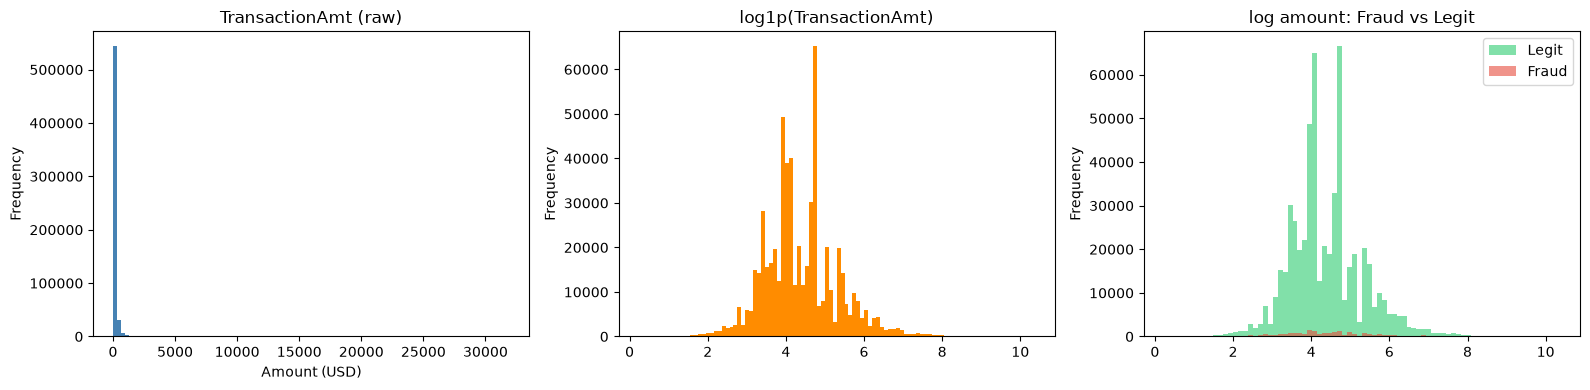


Mann-Whitney U test (amount): p=2.26e-01
According to Mann-Whitney U test there is not enough evidence to conclude that fraud and legitimate transaction amounts are different
  Mean fraud : $149.24
  Mean legit : $134.51
  Median fraud : $75.00
  Median legit : $68.50


In [13]:
# Distribution Plot of TransactionAmt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train['TransactionAmt'].plot.hist(bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('TransactionAmt (raw)')
axes[0].set_xlabel('Amount (USD)')

# Applying Log transformation as TransactionAmt is highly skewed
np.log1p(train['TransactionAmt']).plot.hist(bins=100, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(TransactionAmt)')

# Fraud vs legit amount distributions
train.groupby('isFraud')['TransactionAmt'].apply(np.log1p).unstack().T.plot.hist(
    bins=80, alpha=0.6, ax=axes[2], color=['#2ecc71','#e74c3c']
)
axes[2].set_title('log amount: Fraud vs Legit')
axes[2].legend(['Legit', 'Fraud'])

plt.tight_layout()
plt.show()

# ─── Statistical test for amount difference ───────────────────────
fraud_amt  = train.loc[train['isFraud']==1, 'TransactionAmt']
legit_amt  = train.loc[train['isFraud']==0, 'TransactionAmt']
stat, p    = stats.mannwhitneyu(fraud_amt, legit_amt, alternative='two-sided')
print(f"\nMann-Whitney U test (amount): p={p:.2e}")
if p>0.05: 
    print("According to Mann-Whitney U test there is not enough evidence to conclude that fraud and legitimate transaction amounts are different")
print(f"  Mean fraud : ${fraud_amt.mean():.2f}")
print(f"  Mean legit : ${legit_amt.mean():.2f}")
print(f"  Median fraud : ${fraud_amt.median():.2f}")
print(f"  Median legit : ${legit_amt.median():.2f}")

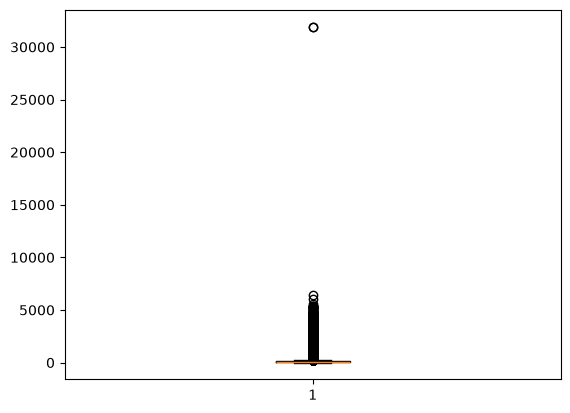

In [14]:
plt.boxplot(train['TransactionAmt']);
# There are so many outliers in TransactionAmt col.

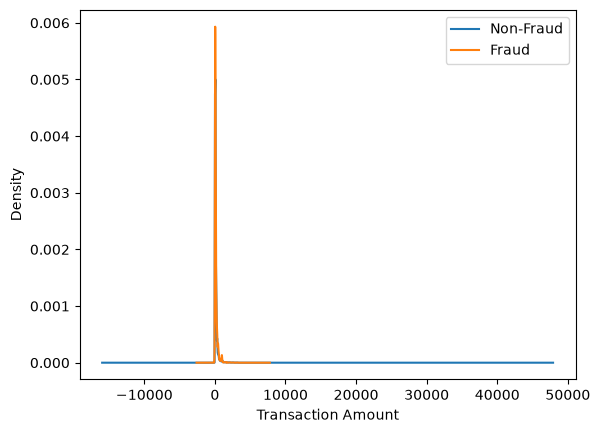

In [15]:
train[train['isFraud'] == 0]['TransactionAmt'].plot(kind='kde', label="Non-Fraud")
train[train['isFraud'] == 1]['TransactionAmt'].plot(kind='kde', label='Fraud')
plt.xlabel("Transaction Amount")
plt.legend()
plt.show()

# The distribution for fraud and non-fraud transactions are almost identical.

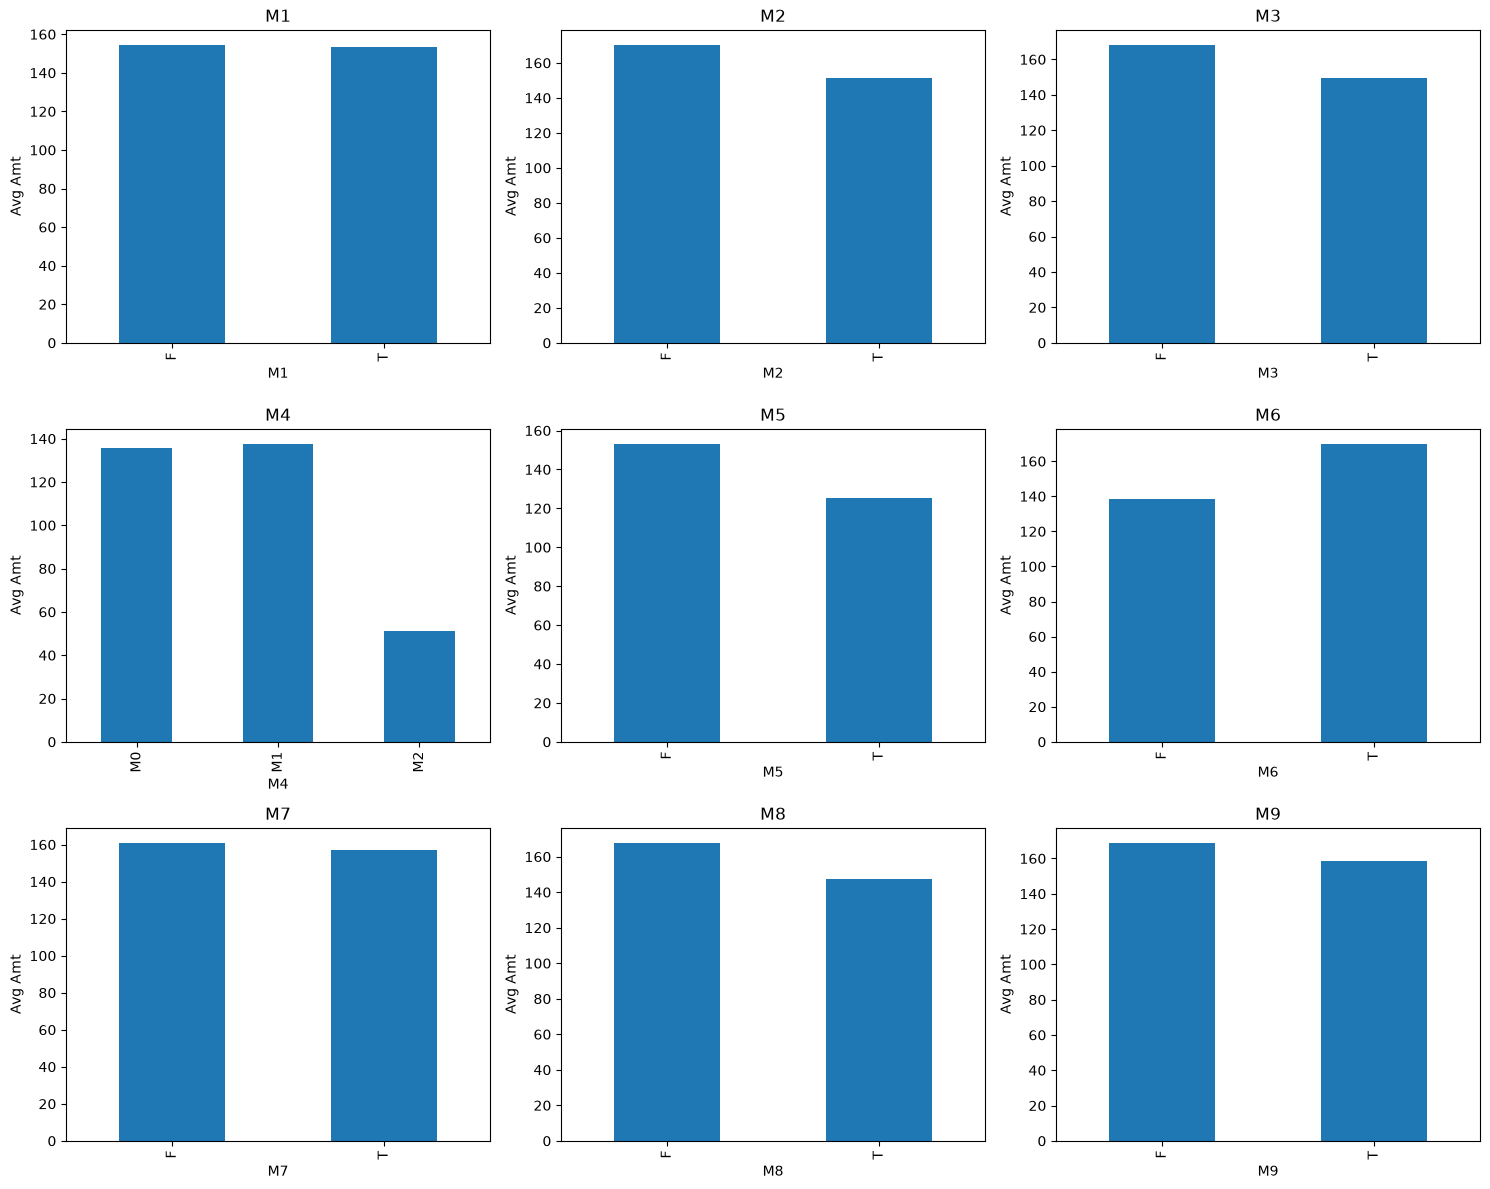

In [16]:
import matplotlib.pyplot as plt

m_cols = [f'M{i}' for i in range(1, 10)]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(m_cols):
    avg_amt = train.groupby(col)['TransactionAmt'].mean()

    avg_amt.plot(
        kind='bar',
        ax=axes[i],
        title=col
    )

    axes[i].set_ylabel('Avg Amt')

plt.tight_layout()
plt.show()

# 3. Time-Based Analysis

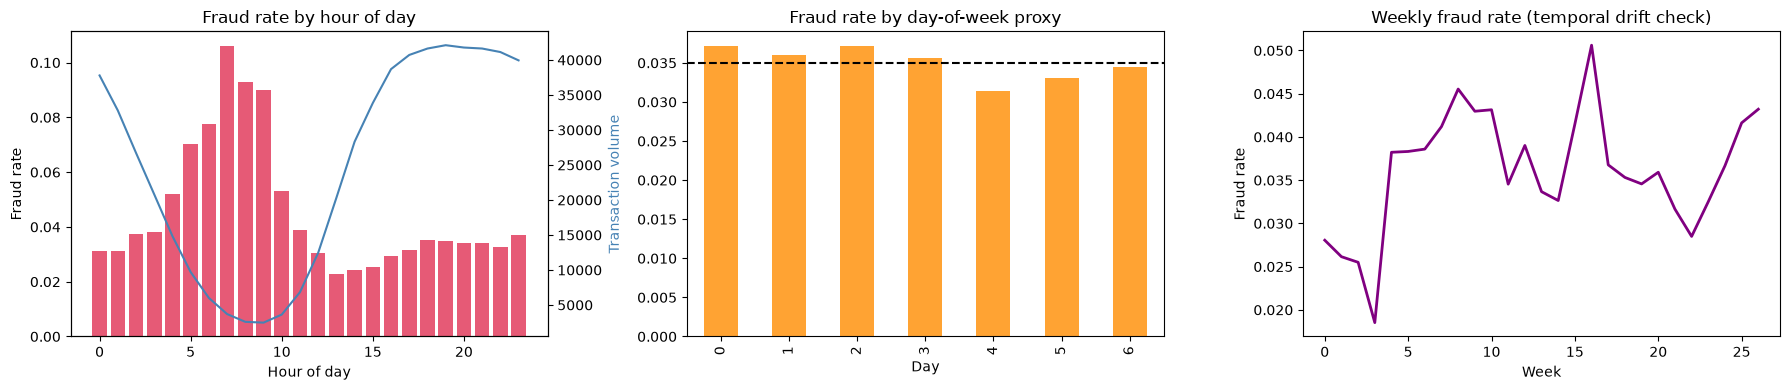

In [17]:
# TransactionDT is seconds offset from a reference point — not a real timestamp
train['hour']    = (train['TransactionDT'] // 3600) % 24
train['day']     = (train['TransactionDT'] // (3600*24)) % 7   
train['week']    = train['TransactionDT'] // (3600*24*7)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Fraud rate by hour-of-day
hourly = train.groupby('hour')['isFraud'].agg(['mean','count'])
ax = axes[0]
ax.bar(hourly.index, hourly['mean'], color='crimson', alpha=0.7, label='Fraud rate')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Fraud rate')
ax.set_title('Fraud rate by hour of day')
ax2 = ax.twinx()
ax2.plot(hourly.index, hourly['count'], color='steelblue', linewidth=1.5, label='Volume')
ax2.set_ylabel('Transaction volume', color='steelblue')

# Fraud rate by day-of-week proxy
daily = train.groupby('day')['isFraud'].mean()
daily.plot.bar(ax=axes[1], color='darkorange', alpha=0.8)
axes[1].axhline(train['isFraud'].mean(), color='black', linestyle='--')
axes[1].set_title('Fraud rate by day-of-week proxy')
axes[1].set_xlabel('Day')

# Rolling fraud rate over time (weekly bins)
weekly = train.groupby('week')['isFraud'].mean()
weekly.plot(ax=axes[2], color='purple', linewidth=2)
axes[2].set_title('Weekly fraud rate (temporal drift check)')
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

# 4. Missing Value Analysis

In [18]:
## Percentage null values in each column
missing_percentages=round((train.isnull().sum() / len(train)) * 100, 2).sort_values(ascending=False)
print(missing_percentages)

id_24            99.20
id_08            99.13
id_21            99.13
id_26            99.13
id_25            99.13
                 ...  
isFraud           0.00
TransactionID     0.00
hour              0.00
day               0.00
week              0.00
Length: 437, dtype: float64


In [19]:
missing_pct = train.groupby('isFraud').apply(
    lambda x: x.isnull().mean() * 100
)

missing_pct

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,day,week
isFraud,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,1.493305,0.267777,0.269532,0.710504,0.268830,...,86.958589,77.229648,77.229648,77.229648,77.229648,77.258426,80.687236,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,2.047137,0.188743,0.198422,1.016309,0.188743,...,83.134104,45.690364,45.690364,45.690364,45.690364,45.743600,58.345836,0.0,0.0,0.0



Columns with >80% missing: 74
Columns with >50% missing: 214
Columns with any missing : 414


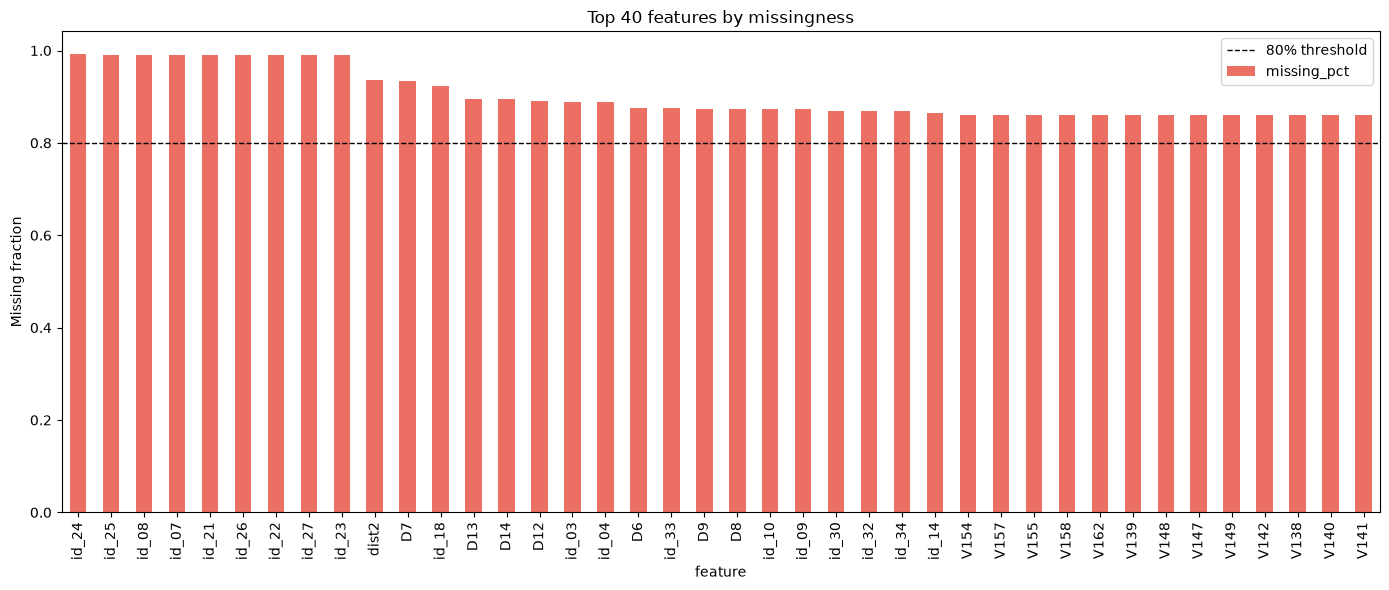

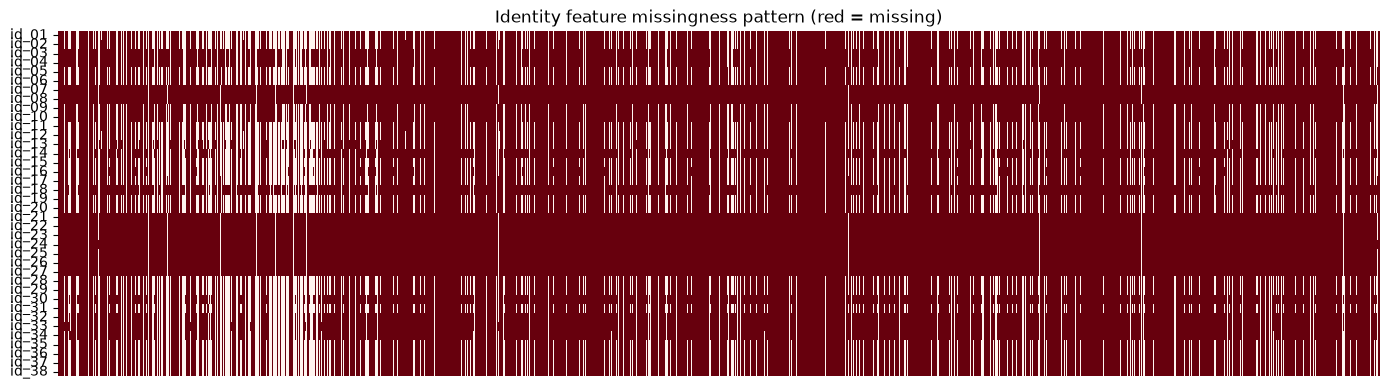


Fraud rate by identity presence:
has_identity
0    0.020939
1    0.078470
Name: isFraud, dtype: float64


In [20]:
# Per-column missingness
miss = train.isnull().mean().sort_values(ascending=False)
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['feature', 'missing_pct']

print(f"\nColumns with >80% missing: {(miss > 0.8).sum()}")
print(f"Columns with >50% missing: {(miss > 0.5).sum()}")
print(f"Columns with any missing : {(miss > 0).sum()}")

# Visualise top-N missing features
top_n = 40
fig, ax = plt.subplots(figsize=(14, 6))
miss_df.head(top_n).plot.bar(x='feature', y='missing_pct', ax=ax, legend=False, color='#e74c3c', alpha=0.8)
ax.axhline(0.8, color='black', linestyle='--', linewidth=1, label='80% threshold')
ax.set_title(f'Top {top_n} features by missingness')
ax.set_ylabel('Missing fraction')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# Missingness heatmap for identity table
# Identity is only joined for ~40% of transactions — itself informative
id_cols = [c for c in train.columns if c.startswith('id')]
plt.figure(figsize=(14, 4))
sns.heatmap(
    train[id_cols].isnull().T,
    cbar=False, yticklabels=True, xticklabels=False,
    cmap='Reds'
)
plt.title('Identity feature missingness pattern (red = missing)')
plt.tight_layout()
plt.show()

# Is missingness itself informative?
# Rows where identity is entirely missing vs not
train['has_identity'] = train[id_cols].notnull().any(axis=1).astype(int)
print("\nFraud rate by identity presence:")
print(train.groupby('has_identity')['isFraud'].mean())

# 5. Categorical Col Analysis

### 1. Card Information Analysis

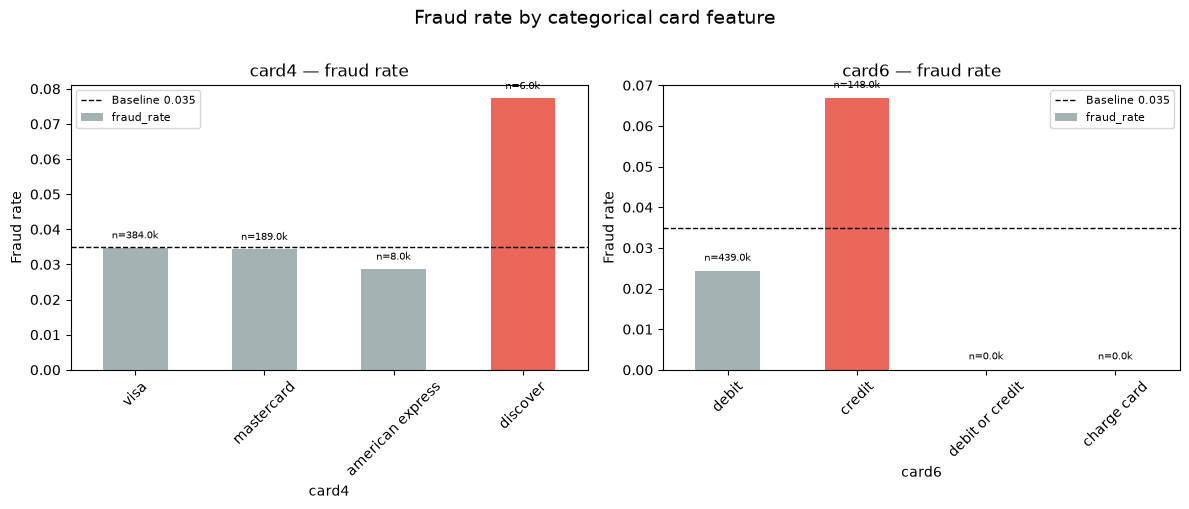

In [21]:
cat_cards= ['card4', 'card6']

def plot_fraud_rate_by_cat(df, col, ax, top_n=15):
    """Bar chart of fraud rate per category, sized by volume."""
    grp = df.groupby(col).agg(
        fraud_rate=('isFraud', 'mean'),
        count=('isFraud', 'count')
    ).sort_values('count', ascending=False).head(top_n)
    
    colors = ['#e74c3c' if r > df['isFraud'].mean() else '#95a5a6'
              for r in grp['fraud_rate']]
    
    bars = grp['fraud_rate'].plot.bar(ax=ax, color=colors, alpha=0.85)
    ax.axhline(df['isFraud'].mean(), color='black', linestyle='--',
               linewidth=1, label=f'Baseline {df["isFraud"].mean():.3f}')
    
    ax.set_title(f'{col} — fraud rate')
    ax.set_ylabel('Fraud rate')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

    for bar, (_, row) in zip(bars.patches, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"n={row['count']//1000}k", ha='center', va='bottom', fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes.flatten(), cat_cards):
    plot_fraud_rate_by_cat(train, col, ax)

plt.suptitle('Fraud rate by categorical card feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2. Address Analysis

In [22]:
# addr1 analysis
print(f"total unique addr1 values {train['addr1'].nunique()}")
fraud_count = (
    train.groupby('addr1')
    .agg(
        total_count   = ('isFraud', 'count'),      
        fraud_count   = ('isFraud', 'sum'),      
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
    .sort_values('fraud_pct', ascending=False) 
    .query('fraud_pct >= 5')                 
)

fraud_count
# Addr 208 and 325 contributes in most of the fraud cases

total unique addr1 values 332


,total_count,fraud_count,fraud_pct
addr1,,,
305.0,9,6,66.67
483.0,23,13,56.52
466.0,2,1,50.00
501.0,4,2,50.00
471.0,2,1,50.00
391.0,35,16,45.71
431.0,38,13,34.21
260.0,6,2,33.33
432.0,38,11,28.95


In [23]:
# addr2 analysis
print(f"total unique addr1 values {train['addr2'].nunique()}")
fraud_count = (
    train.groupby('addr2')
    .agg(
        total_count   = ('isFraud', 'count'),      
        fraud_count   = ('isFraud', 'sum'),      
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
    .sort_values('fraud_pct', ascending=False)  
    .query('fraud_pct >= 5')                  
)

fraud_count

#  address 10, 51 in addr2 contributes fraud in most cases

total unique addr1 values 74


,total_count,fraud_count,fraud_pct
addr2,,,
10.0,8,8,100.00
51.0,4,4,100.00
75.0,1,1,100.00
82.0,1,1,100.00
46.0,3,3,100.00
92.0,2,2,100.00
38.0,3,2,66.67
65.0,82,44,53.66
36.0,2,1,50.00


### 3. Email domain Analysis

                 fraud_count  total_count  fraud_pct
P_emaildomain                                       
mail.com                 106          559      18.96
outlook.es                57          438      13.01
aim.com                   40          315      12.70
outlook.com              482         5096       9.46
hotmail.es                20          305       6.56
live.com.mx               41          749       5.47
hotmail.com             2396        45250       5.30
gmail.com               9943       228355       4.35
yahoo.fr                   5          143       3.50
embarqmail.com             9          260       3.46
mac.com                   14          436       3.21
icloud.com               197         6267       3.14
comcast.net              246         7888       3.12
charter.net               25          816       3.06
frontier.com               8          280       2.86
bellsouth.net             53         1909       2.78
live.com                  84         3041     

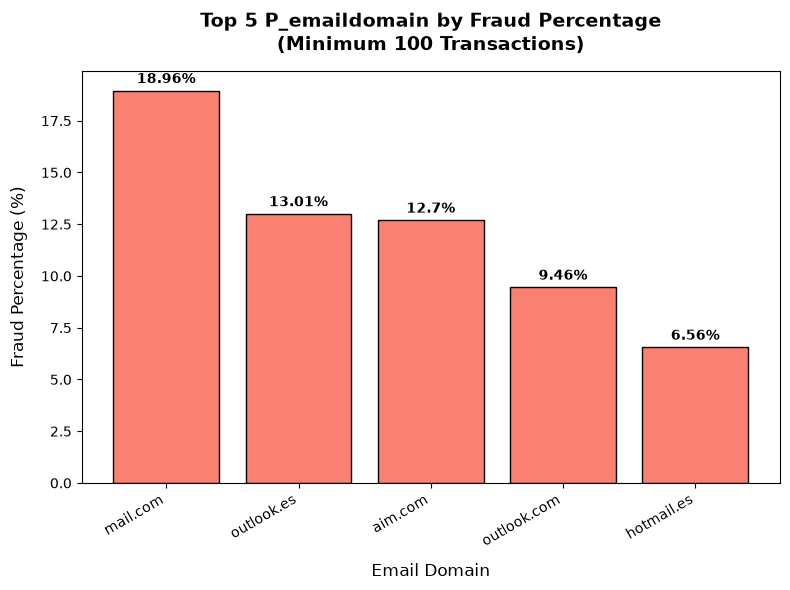

In [24]:
# P_emaildomain — the email domain of the purchaser (the person making the transaction). This is the email address the buyer used when placing the order.
# R_emaildomain — the email domain of the recipient (the person receiving the goods/services). This could be a shipping address email, a billing contact, or a secondary account.

# Transaction example:
#   card1          : 1234
#   P_emaildomain  : gmail.com      ← buyer's email provider
#   R_emaildomain  : yahoo.com      ← recipient's email provider

# Fraud count, total count, and fraud percentage per email domain
email_fraud_stats = (
    train.groupby('P_emaildomain')
    .agg(
        fraud_count   = ('isFraud', 'sum'),      
        total_count   = ('isFraud', 'count'),      
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
    .sort_values('fraud_pct', ascending=False)  
    .query('total_count >= 100')                  # remove domains with <100 transactions
                                                  # (small sample = unreliable %)
)

print(email_fraud_stats.head(20))

top_5_emails = email_fraud_stats.head(5)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(top_5_emails.index, top_5_emails['fraud_pct'], color='salmon', edgecolor='black')

ax.set_title('Top 5 P_emaildomain by Fraud Percentage\n(Minimum 100 Transactions)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Email Domain', fontsize=12, labelpad=10)
ax.set_ylabel('Fraud Percentage (%)', fontsize=12, labelpad=10)

ax.set_xticklabels(top_5_emails.index, rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,   
        yval + 0.2,                        
        f"{yval}%",                       
        ha='center', va='bottom',        
        fontweight='bold', color='black'
    )

plt.tight_layout()

plt.show()

               total_count  fraud_count  fraud_pct
R_emaildomain                                     
mail.com               122           46      37.70
outlook.com           2507          414      16.51
outlook.es             433           57      13.16
icloud.com            1398          180      12.88
gmail.com            57147         6811      11.92
hotmail.com          27509         2140       7.78
hotmail.es             292           20       6.85
live.com.mx            754           44       5.84
yahoo.com            11842          610       5.15
live.com               762           38       4.99
charter.net            127            5       3.94
ymail.com              207            8       3.86
yahoo.fr               137            5       3.65
aol.com               3701          129       3.49
anonymous.com        20529          598       2.91
cox.net                459           11       2.40
me.com                 556           11       1.98
comcast.net           1812     

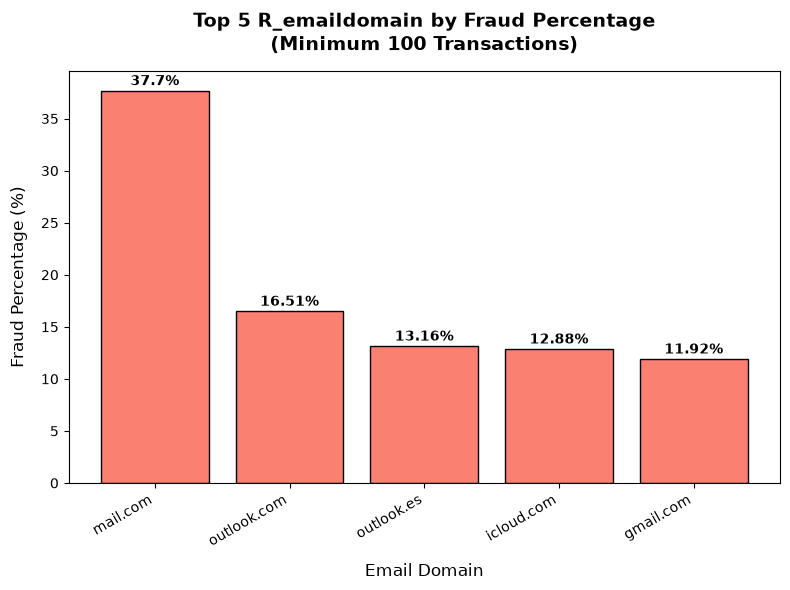

In [25]:
# R_emaildomain  analysis
email_fraud_stats = (
    train.groupby('R_emaildomain')
    .agg(
        total_count   = ('isFraud', 'count'),      # total transactions
        fraud_count   = ('isFraud', 'sum'),       # number of fraud cases
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
    .sort_values('fraud_pct', ascending=False)  # sort by volume of fraud
    .query('total_count >= 100')                  # remove domains with <100 transactions
                                                  # (small sample = unreliable %)
)

print(email_fraud_stats.head(20))

top_5_emails = email_fraud_stats.head(5)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(top_5_emails.index, top_5_emails['fraud_pct'], color='salmon', edgecolor='black')

ax.set_title('Top 5 R_emaildomain by Fraud Percentage\n(Minimum 100 Transactions)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Email Domain', fontsize=12, labelpad=10)
ax.set_ylabel('Fraud Percentage (%)', fontsize=12, labelpad=10)
ax.set_xticklabels(top_5_emails.index, rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,  
        yval + 0.2,                       
        f"{yval}%",                       
        ha='center', va='bottom',          
        fontweight='bold', color='black'
    )

plt.tight_layout()

plt.show()

In [26]:
# How often do sender and receiver domains mismatch?

# Mismatch between P and R is suspicious
# If buyer and recipient use completely different email providers
# it may indicate the buyer is shipping to a different person (reshipping fraud)

# 1. Flag whether a mismatch occurred (True/False)
train['is_email_mismatch'] = train['P_emaildomain'] != train['R_emaildomain']

# 2. Group by that mismatch flag to see if mismatched emails have higher fraud rates
mismatch_stats = (
    train.groupby('is_email_mismatch')
    .agg(
        fraud_count = ('isFraud', 'sum'),
        total_count = ('isFraud', 'count')
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
)

print(mismatch_stats)
# Fraud rate when emails match    : 9.65%   
# Fraud rate when emails mismatch : 2.21%   

                   fraud_count  total_count  fraud_pct
is_email_mismatch                                     
False                     9892       102504       9.65
True                     10771       488036       2.21


In [27]:
# Missing P_emaildomain means no email was collected
# This often happens in API/card-present transactions
# or when a fraudster deliberately skips the email field

train['P_email_missing'] = train['P_emaildomain'].isnull().astype(int)
train['R_email_missing'] = train['R_emaildomain'].isnull().astype(int)

p_stats = train.groupby('P_email_missing')['isFraud'].mean() * 100
r_stats = train.groupby('R_email_missing')['isFraud'].mean() * 100

email_fraud_comparison = pd.DataFrame({
    'Purchaser Email (P)': [f"{p_stats[0]:.2f}%", f"{p_stats[1]:.2f}%"],
    'Recipient Email (R)': [f"{r_stats[0]:.2f}%", f"{r_stats[1]:.2f}%"]
}, index=['Email Provided', 'Email Missing'])

print(email_fraud_comparison)
# P_email_missing
# 0    3.6    ← email present (email present have high fraud percentage)
# 1    2.9    ← email missing

               Purchaser Email (P) Recipient Email (R)
Email Provided               3.60%               8.18%
Email Missing                2.95%               2.08%


### 4. Device Analysis

In [28]:
# Is fraud more common on mobile or desktop?
email_fraud_stats = (
    train.groupby('DeviceType')
    .agg(
        fraud_count   = ('isFraud', 'sum'),      
        total_count   = ('isFraud', 'count'),     
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
    .sort_values('fraud_pct', ascending=False) 
    .query('total_count >= 100')                  
                                                 
)

print(email_fraud_stats.head(20))
# More frauds happens through mobile than desktop

            fraud_count  total_count  fraud_pct
DeviceType                                     
mobile             5657        55645      10.17
desktop            5554        85165       6.52


In [29]:
# DeviceType missing analysis
train['DeviceType_missing'] = train['DeviceType'].isnull().astype(int)

# 2. Calculate the fraud rates and convert to a clean DataFrame
fraud_by_missing = (
    train.groupby('DeviceType_missing')['isFraud']
    .mean()
    .to_frame(name='Fraud Rate (%)')
    .multiply(100)
    .round(2)
)

fraud_by_missing.index = ['Device Type Present', 'Device Type Missing']
print(fraud_by_missing)

                     Fraud Rate (%)
Device Type Present            7.96
Device Type Missing            2.10


                                     fraud_count  total_count  fraud_pct
DeviceInfo                                                              
hi6210sft Build/MRA58K                       180          190      94.74
SM-A300H Build/LRX22G                        169          203      83.25
SM-J320M Build/LMY47V                         57          171      33.33
WAS-LX3 Build/HUAWEIWAS-LX3                   28          108      25.93
Moto Z2 Play Build/NPSS26.118-19-14           30          129      23.26
Moto E (4) Plus Build/NMA26.42-69             32          160      20.00
SM-J701M Build/NRD90M                         30          154      19.48
SM-G955F Build/NRD90M                         26          134      19.40
Moto E (4) Build/NMA26.42-69                  23          125      18.40
SM-A720F Build/NRD90M                         22          120      18.33
Moto G (4) Build/NPJ25.93-14.7                40          219      18.26
rv:58.0                                       49   

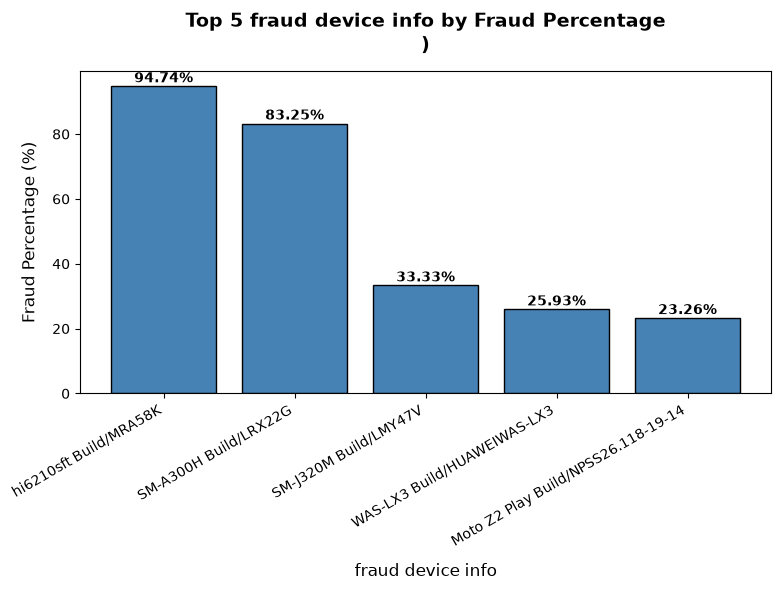

In [30]:
# Which devices are most associated with fraud?
fraud_device_info = (
    train.groupby('DeviceInfo')
    .agg(
        fraud_count   = ('isFraud', 'sum'),       
        total_count   = ('isFraud', 'count'),      
    )
    .assign(
        fraud_pct = lambda x: (x['fraud_count'] / x['total_count'] * 100).round(2)
    )
    .sort_values('fraud_pct', ascending=False)  
    .query('total_count >= 100')                 
                                                  
)

print(fraud_device_info.head(20))


top5_fraud_device_info = fraud_device_info.head(5)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(top5_fraud_device_info.index, top5_fraud_device_info['fraud_pct'], color='steelblue', edgecolor='black')

ax.set_title('Top 5 fraud device info by Fraud Percentage\n)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('fraud device info', fontsize=12, labelpad=10)
ax.set_ylabel('Fraud Percentage (%)', fontsize=12, labelpad=10)
ax.set_xticklabels(top5_fraud_device_info.index, rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.2,                        
        f"{yval}%",                        
        ha='center', va='bottom',          
        fontweight='bold', color='black'
    )

plt.tight_layout()
plt.show()
plt.savefig("")
## hi6210sft Build/MRA58K , SM-A300H Build/LRX22G these devices causes most of the frauds

### 5. Identity Features Analysis

In [31]:
# For continuous id columns 
num_id_cols = [c for c in id_cols
               if train[c].dtype in [np.float32, np.float64, np.int32, np.int64]
               and train[c].nunique() > 10]

pb_scores = {}

for col in num_id_cols:
    clean = train[[col, 'isFraud']].dropna()
    if len(clean) < 1000:
        continue
    
    corr, pvalue = stats.pointbiserialr(clean['isFraud'], clean[col])
    pb_scores[col] = {
        'correlation' : round(corr, 4),
        'abs_corr'    : round(abs(corr), 4),
        'p_value'     : round(pvalue, 6),
        'significant' : pvalue < 0.05
    }

pb_df = (pd.DataFrame(pb_scores).T.sort_values('abs_corr', ascending=False))

print("\nPoint-biserial correlation with isFraud:")
print(pb_df.to_string())


Point-biserial correlation with isFraud:
      correlation abs_corr   p_value significant
id_17      0.1501   0.1501       0.0        True
id_01     -0.1201   0.1201       0.0        True
id_22      0.1184   0.1184       0.0        True
id_26      0.0996   0.0996       0.0        True
id_07     -0.0848   0.0848       0.0        True
id_21      0.0635   0.0635  0.000005        True
id_20      0.0616   0.0616       0.0        True
id_04     -0.0597   0.0597       0.0        True
id_08     -0.0575   0.0575  0.000036        True
id_14      0.0573   0.0573       0.0        True
id_18        0.05     0.05       0.0        True
id_02      0.0494   0.0494       0.0        True
id_19     -0.0417   0.0417       0.0        True
id_03      0.0415   0.0415       0.0        True
id_25       0.034    0.034  0.014728        True
id_09      0.0294   0.0294       0.0        True
id_06     -0.0271   0.0271       0.0        True
id_13     -0.0195   0.0195       0.0        True
id_10       0.011    0.011 

In [32]:
# 1. Heavy Hitters (Top Predictors)
# Not all identity features contribute equally to fraud detection. A few variables exhibit noticeably stronger relationships with the target variable (isFraud):

# Feature	Correlation with Fraud	Interpretation
# id_17	0.1501	Strongest positive predictor. Higher values are associated with a greater likelihood of fraud.
# id_01	-0.1201	Strongest negative predictor. Lower values are associated with a higher fraud risk.
# id_22	0.1184	Moderately strong positive relationship with fraud.
# id_26	0.0996	Also shows meaningful positive association with fraudulent transactions.

# Modeling Implication:
# These features (id_17, id_01, id_22, and id_26) should be prioritized during feature engineering and model development. In tree-based models such as XGBoost and LightGBM, they are likely to rank among the most important features.

# 2. Overall Correlations Are Relatively Weak
# Although the above features are statistically relevant, the strongest correlation observed is only 0.1501.
# In traditional statistical analysis:
# Correlation values below 0.30 are generally considered weak.
# This does not imply that the features lack predictive value.

# Why are correlations low?
# Fraud detection datasets are typically:
# Highly imbalanced (fraud cases are rare).
# Characterized by complex, non-linear relationships.
# As a result, many fraud indicators only become predictive within specific value ranges or through interactions with other variables. Linear correlation measures cannot fully capture these patterns.

# 3. Statistical Significance vs. Predictive Power
# Most features have:
# p-value ≈ 0
# significant = True
# At first glance, this suggests that nearly every feature is important.
# However, large datasets can make even tiny correlations appear statistically significant.

# For example:
# A feature such as id_11 with a correlation of 0.0079 may achieve a near-zero p-value simply because the sample size is extremely large.
# Statistical significance does not necessarily translate into meaningful predictive power.

# Practical Interpretation:
# Features with |correlation| > 0.10 deserve closer attention.
# Features with |correlation| < 0.05 generally provide little standalone predictive value.
# Low-correlation variables may still contribute through feature interactions captured by advanced machine learning models.

In [33]:
#Method 3 — For categorical id columns, fraud rate per category

cat_id_cols = [c for c in id_cols
               if train[c].dtype in ['object', 'category']
               or train[c].nunique() < 10]

print(f"\nCategorical identity columns: {cat_id_cols}")

for col in cat_id_cols:
    if col not in train.columns:
        continue
    
    stats_df = (
        train.groupby(col, observed=True)
        .agg(
            fraud_count = ('isFraud', 'sum'),
            total       = ('isFraud', 'count'),
        )
        .assign(fraud_pct = lambda x: (x['fraud_count'] / x['total'] * 100).round(2))
        .sort_values('fraud_pct', ascending=False)
    )
    
    baseline = train['isFraud'].mean() * 100
    print(f"\n{col} (baseline: {baseline:.2f}%)")
    print(stats_df.to_string())


Categorical identity columns: ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_32', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

id_12 (baseline: 3.50%)
          fraud_count   total  fraud_pct
id_12                                   
NotFound        10049  123025       8.17
Found            1269   21208       5.98

id_15 (baseline: 3.50%)
         fraud_count  total  fraud_pct
id_15                                 
Found           7118  67728      10.51
Unknown         1070  11645       9.19
New             3034  61612       4.92

id_16 (baseline: 3.50%)
          fraud_count  total  fraud_pct
id_16                                  
Found            7112  66324      10.72
NotFound         3040  63016       4.82

id_23 (baseline: 3.50%)
                      fraud_count  total  fraud_pct
id_23                                              
IP_PROXY:ANONYMOUS            147   1071      13.73
IP_PROXY:TRANSPARENT          245   3489       7.02
IP_PROXY:HIDDEN         

In [34]:
results_list = []

for col in cat_id_cols:
    # Skip if the column is entirely missing or has only 1 unique value (can't cross-tabulate)
    if train[col].dropna().nunique() <= 1:
        continue
        
    # 1. Create the contingency table against the target variable
    contingency_table = pd.crosstab(train[col], train['isFraud'])
    
    # 2. Run the Chi-Square Test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 3. Calculate Cramér's V
    total_obs = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    
    if min_dim == 0:
        cramer_v = 0
    else:
        cramer_v = np.sqrt(chi2 / (total_obs * min_dim))
    
    results_list.append({
        'Feature': col,
        'Chi2_Stat': round(chi2, 2),
        'P_Value': p_value,
        'Cramer_V': round(cramer_v, 4),
        'Is_Significant': p_value < 0.05
    })

cat_test_results = pd.DataFrame(results_list)

cat_test_results = cat_test_results.sort_values('Cramer_V', ascending=False).reset_index(drop=True)

print("=== Categorical Features Ranked by Cramér's V ===")
print(cat_test_results)

=== Categorical Features Ranked by Cramér's V ===
   Feature  Chi2_Stat        P_Value  Cramer_V  Is_Significant
0    id_35    2888.47   0.000000e+00    0.1431            True
1    id_16    1553.79   0.000000e+00    0.1096            True
2    id_23      55.15   1.060176e-12    0.1033            True
3    id_15    1399.95  1.008525e-304    0.0996            True
4    id_29    1351.99  5.685467e-296    0.0979            True
5    id_28    1216.98  1.247881e-266    0.0929            True
6    id_32     513.29  6.286447e-111    0.0813            True
7    id_38     701.74  1.250925e-154    0.0706            True
8    id_34     187.33   2.306615e-40    0.0491            True
9    id_36     194.55   3.225181e-44    0.0371            True
10   id_12     119.09   9.994885e-28    0.0287            True
11   id_37      95.85   1.240822e-22    0.0261            True
12   id_27       0.40   5.245961e-01    0.0088           False


In [35]:
# ### 1. The Top Tier (Moderate Predictors)

# **id_35 (0.1431), id_16 (0.1096), and id_23 (0.1033)** are your strongest categorical features.
# A Cramér's V score above **0.10** indicates a **moderate association** with fraud. This means that the fraud rate changes noticeably depending on which category a transaction falls into for these columns.
# 💡 **Feature Insight:**
# In the original IEEE-CIS fraud dataset, **id_35** and **id_16** are typically binary flags (such as True/False or Found/NotFound indicators related to proxy use, device characteristics, or security matches), while **id_23** corresponds to device details such as screen resolution or specific connection types.
# Your model will heavily utilize these three features.
# ---

# ### 2. The Subtle Signals (Weak but Useful)
# **id_15 through id_38 (Scores between 0.0706 and 0.0996)**
# While statistically weak on their own, these features still carry a distinct signal. Because their p-values are effectively **0** (e.g., 0.000000e+00 or extremely small scientific notation values such as 1.00e-304), we know these associations are highly stable and unlikely to be due to random sampling.
# Tree-based machine learning algorithms such as LightGBM, XGBoost, and CatBoost are particularly effective at combining multiple weak features to create highly predictive non-linear decision rules.
# **Recommendation:** Keep all of these features.

# ---

# ### 3. The Low-Value Group
# **id_34, id_36, id_12, and id_37 (Scores below 0.05)**
# These features exhibit very low Cramér's V values, suggesting that fraud rates remain nearly identical across their categories.
# For example, if **id_12** has a fraud rate of **3.5%** for one category, another category may have a fraud rate of approximately **3.4%**, indicating minimal discriminatory power.
# Although these variables are statistically significant due to the large sample size, their standalone practical contribution is extremely limited.

# ---

# ### 4. The Dead Weight (Drop Candidate)
# **id_27** has a Cramér's V value of **0.0088** and an **Is_Significant = False** result (p-value = **0.52**).
# A p-value greater than **0.05** indicates that any observed variation in fraud rates across categories is consistent with random chance.
# 🛠 **Action Item:**
# You can safely drop **id_27** from the dataset. It provides virtually no predictive information and is likely to contribute only noise to the model.


In [36]:
#Method 2 — AUC score per column 

# AUC of each identity column alone as a fraud predictor
# AUC > 0.55 = informative, > 0.60 = strong signal
auc_scores = {}

for col in id_cols:
    clean = train[[col, 'isFraud']].dropna()
    if len(clean) < 1000 or clean[col].nunique() < 2:
        continue
    
    try:
        if clean[col].dtype in ['object', 'category']:
            target_map = clean.groupby(col)['isFraud'].mean()
            encoded = clean[col].map(target_map)
        else:
            encoded = clean[col]
        
        auc = roc_auc_score(clean['isFraud'], encoded)
        auc_scores[col] = max(auc, 1 - auc)
    
    except Exception:
        continue

auc_df = pd.Series(auc_scores).sort_values(ascending=False).reset_index()
auc_df.columns = ['feature', 'auc']
auc_df['signal'] = pd.cut(
    auc_df['auc'],
    bins  = [0, 0.52, 0.55, 0.60, 1.0],
    labels= ['noise', 'weak', 'moderate', 'strong']
)

print("\nIdentity column AUC scores (higher = more informative):")
print(auc_df.to_string(index=False))
# id_17, id_01 , id_07 ,id_26 are most informative id columns


Identity column AUC scores (higher = more informative):
feature      auc   signal
  id_17 0.642762   strong
  id_01 0.617777   strong
  id_07 0.600658   strong
  id_26 0.596308 moderate
  id_32 0.580531 moderate
  id_20 0.568585 moderate
  id_18 0.563674 moderate
  id_08 0.562463 moderate
  id_14 0.561905 moderate
  id_22 0.558268 moderate
  id_02 0.554853 moderate
  id_06 0.551362 moderate
  id_19 0.543227     weak
  id_21 0.537329     weak
  id_25 0.531125     weak
  id_24 0.526137     weak
  id_09 0.523173     weak
  id_03 0.520770     weak
  id_13 0.514885    noise
  id_05 0.512051    noise
  id_04 0.506673    noise
  id_10 0.502023    noise
  id_11 0.501937    noise


In [37]:
# KS Test (Kolmogorov-Smirnov)
# Measures the maximum distance between the cumulative distribution functions of two groups. It's asking: "At what point do the two distributions diverge the most, and by how much?"
# Fraud CDF    ─────╮
#                   │  ← KS statistic = this gap
# Legit CDF  ───────╯

# KS statistic — ranges 0 to 1. Higher = more different distributions
# p-value — below 0.05 means the difference is statistically significant
# Best for — continuous numeric features (TransactionAmt, D-cols, id numeric cols)


# Mann-Whitney U Test
# Ranks all values from both groups together and checks if one group tends to rank higher than the other. It's asking: "Do fraud transactions tend to have higher (or lower) values than legit ones?"

# U statistic — how many fraud values rank above legit values
# p-value — below 0.05 means the ranking difference is significant
# Best for — when you care about direction (is fraud higher or lower?)
# More robust than KS for heavy-tailed distributions like TransactionAmt

### 6. M1-M9

In [38]:
# M1  — name on card matches billing name
# M2  — address matches card billing address  
# M3  — phone number matches card records
# M4  — bank match result (has multiple categories: M0/M1/M2)
# M5  — email matches card records
# M6  — billing address verified
# M7  — card present/not present flag
# M8  — unknown match flag
# M9  — unknown match flag

train['M9'].value_counts()

M9
T    205656
F     38632
Name: count, dtype: int64

In [39]:
m_cols = [c for c in train.columns if c.startswith('M')]
baseline = train['isFraud'].mean()
print(f"M columns found : {m_cols}")

print(f"Baseline fraud  : {baseline:.4%}")

M columns found : ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Baseline fraud  : 3.4990%


In [40]:
# Basic distribution and missingness

# Value counts + missingness for every M column
print("="*60)
for col in m_cols:
    total    = len(train)
    missing  = train[col].isnull().sum()
    print(f"\n{col}")
    print(f"  Missing : {missing:,} ({missing/total:.1%})")
    print(train[col].value_counts(dropna=False)
                    .rename('count')
                    .to_frame()
                    .assign(pct=lambda x: (x['count']/total*100).round(2))
                    .to_string())


M1
  Missing : 271,100 (45.9%)
      count    pct
M1                
T    319415  54.09
NaN  271100  45.91
F        25   0.00

M2
  Missing : 271,100 (45.9%)
      count    pct
M2                
T    285468  48.34
NaN  271100  45.91
F     33972   5.75

M3
  Missing : 271,100 (45.9%)
      count    pct
M3                
NaN  271100  45.91
T    251731  42.63
F     67709  11.47

M4
  Missing : 281,444 (47.7%)
      count    pct
M4                
NaN  281444  47.66
M0   196405  33.26
M2    59865  10.14
M1    52826   8.95

M5
  Missing : 350,482 (59.3%)
      count    pct
M5                
NaN  350482  59.35
F    132491  22.44
T    107567  18.22

M6
  Missing : 169,360 (28.7%)
      count    pct
M6                
F    227856  38.58
T    193324  32.74
NaN  169360  28.68

M7
  Missing : 346,265 (58.6%)
      count    pct
M7                
NaN  346265  58.64
F    211374  35.79
T     32901   5.57

M8
  Missing : 346,252 (58.6%)
      count    pct
M8                
NaN  346252  58.63
F  

In [41]:
# EDA 2 — Fraud rate by each value

print(f"\nBaseline fraud rate: {baseline:.4%}")
print("="*60)

for col in m_cols:
    print(f"\n{col}")
    stats_df = (
        train.groupby(col, observed=True, dropna=False)
        .agg(
            count       = ('isFraud', 'count'),
            fraud_count = ('isFraud', 'sum'),
        )
        .assign(
            fraud_pct   = lambda x: (x['fraud_count'] / x['count'] * 100).round(3),
            vs_baseline = lambda x: ((x['fraud_count']/x['count']) - baseline).round(4),
            pct_of_data = lambda x: (x['count'] / len(train) * 100).round(1),
            risk        = lambda x: x['fraud_count']/x['count'] > baseline
        )
    )
    print(stats_df.to_string())


Baseline fraud rate: 3.4990%

M1
      count  fraud_count  fraud_pct  vs_baseline  pct_of_data   risk
M1                                                                  
F        25            0      0.000      -0.0350          0.0  False
T    319415         6342      1.986      -0.0151         54.1  False
NaN  271100        14321      5.283       0.0178         45.9   True

M2
      count  fraud_count  fraud_pct  vs_baseline  pct_of_data   risk
M2                                                                  
F     33972         1184      3.485      -0.0001          5.8  False
T    285468         5158      1.807      -0.0169         48.3  False
NaN  271100        14321      5.283       0.0178         45.9   True

M3
      count  fraud_count  fraud_pct  vs_baseline  pct_of_data   risk
M3                                                                  
F     67709         2049      3.026      -0.0047         11.5  False
T    251731         4293      1.705      -0.0179         42.6

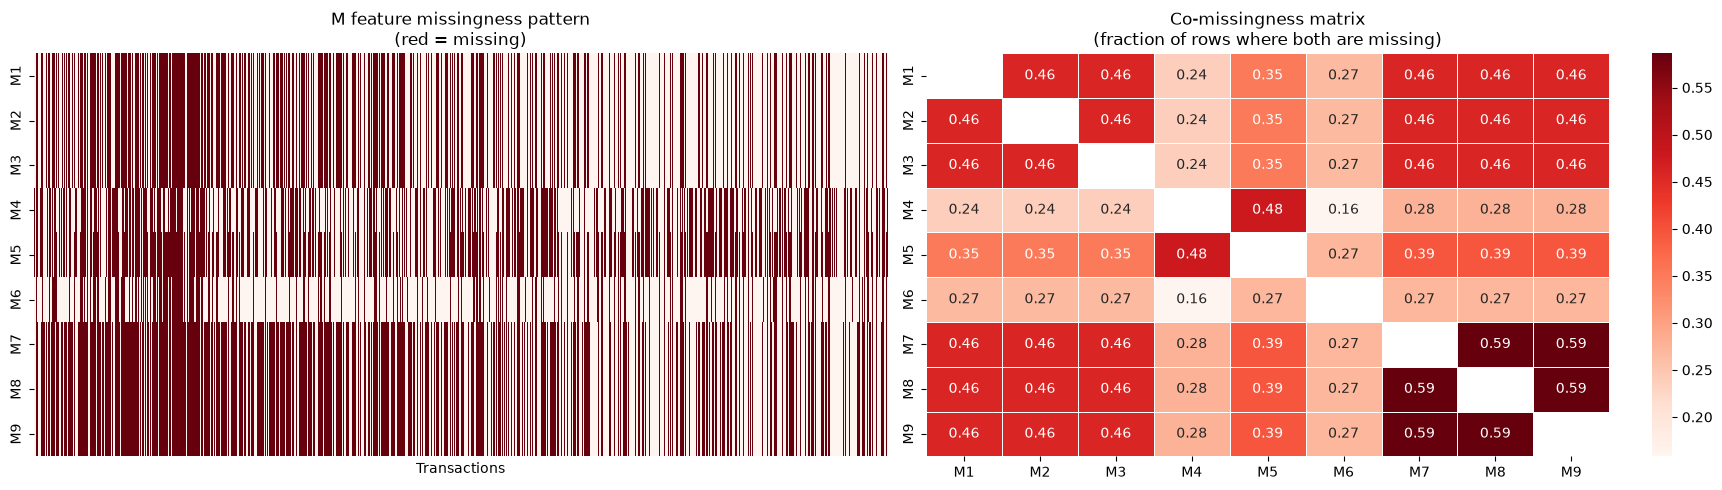

In [42]:
# EDA 3 — Missingness heatmap

# Do M columns go missing together? (pattern analysis)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Heatmap of missingness pattern ───────────────────────────────
miss_matrix = train[m_cols].isnull().astype(int)
sns.heatmap(
    miss_matrix.T,
    ax=axes[0],
    cbar=False,
    yticklabels=m_cols,
    xticklabels=False,
    cmap='Reds'
)
axes[0].set_title('M feature missingness pattern\n(red = missing)')
axes[0].set_xlabel('Transactions')

# ── Co-missingness matrix — which M cols go missing together ──────
co_miss = miss_matrix.T.dot(miss_matrix) / len(train)
mask = np.eye(len(m_cols), dtype=bool)   # hide diagonal
sns.heatmap(
    co_miss,
    annot=True, fmt='.2f',
    mask=mask,
    cmap='Reds',
    ax=axes[1],
    xticklabels=m_cols,
    yticklabels=m_cols,
    linewidths=0.5
)
axes[1].set_title('Co-missingness matrix\n(fraction of rows where both are missing)')

plt.tight_layout()
plt.show()

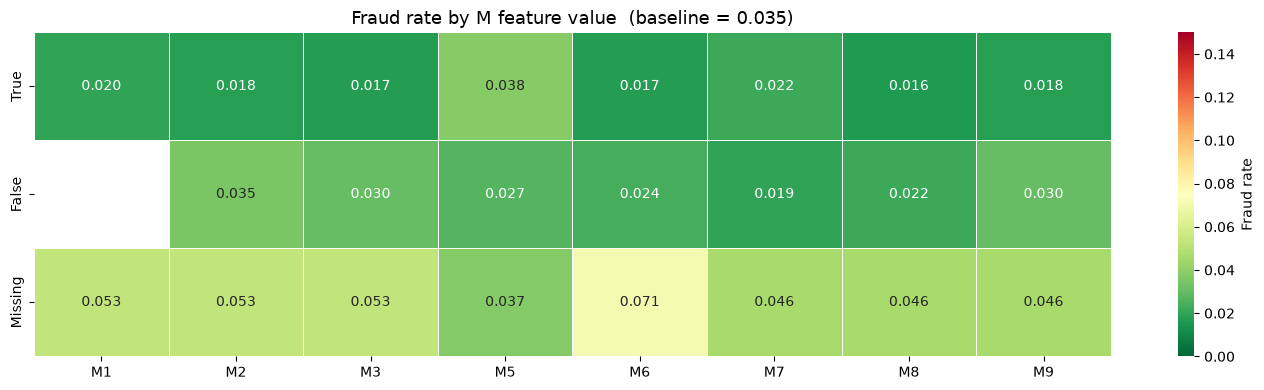

In [43]:
#Fraud rate heatmap (value × column)

# Build a clean heatmap: rows = T/F/Missing, cols = M features
heat_rows = []

for col in [c for c in m_cols if c != 'M4']:
    for val, label in [('T','True'), ('F','False'), (np.nan,'Missing')]:
        mask = train[col].isnull() if pd.isnull(val) else train[col] == val
        if mask.sum() < 50:
            continue
        heat_rows.append({
            'column'     : col,
            'value'      : label,
            'fraud_rate' : train.loc[mask, 'isFraud'].mean(),
            'count'      : mask.sum()
        })

heat_df = (pd.DataFrame(heat_rows)
             .pivot(index='value', columns='column', values='fraud_rate'))

# Reorder rows
heat_df = heat_df.reindex(['True', 'False', 'Missing'])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heat_df,
    annot=True, fmt='.3f',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=0.5,
    vmin=0, vmax=0.15,
    cbar_kws={'label': 'Fraud rate'}
)
ax.set_title(f'Fraud rate by M feature value  '
             f'(baseline = {baseline:.3f})',
             fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [44]:
# EDA 5 — Chi-square test (statistical significance)

# Is the fraud rate difference across T/F/NaN statistically significant?
from scipy.stats import chi2_contingency

print("Chi-square test — is fraud rate different across M values?")
print(f"{'Column':<8} {'Chi2':>10} {'p-value':>12} {'Significant':>12} {'Cramer V':>10}")
print("-"*55)

for col in m_cols:
    # Contingency table: rows = M value categories, cols = fraud/legit
    temp = train[[col, 'isFraud']].copy()
    temp[col] = temp[col].fillna('Missing').astype(str)

    ct = pd.crosstab(temp[col], temp['isFraud'])
    if ct.shape[0] < 2:
        continue

    chi2, p, dof, _ = chi2_contingency(ct)

    # Cramer's V — effect size (0=no association, 1=perfect)
    n       = ct.sum().sum()
    cramers = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    sig = 'YES ***' if p < 0.001 else ('YES *' if p < 0.05 else 'no')
    print(f"{col:<8} {chi2:>10.1f} {p:>12.2e} {sig:>12} {cramers:>10.4f}")

Chi-square test — is fraud rate different across M values?
Column         Chi2      p-value  Significant   Cramer V
-------------------------------------------------------
M1           4721.8     0.00e+00      YES ***     0.0894
M2           4974.8     0.00e+00      YES ***     0.0918
M3           4997.2     0.00e+00      YES ***     0.0920
M4          13356.2     0.00e+00      YES ***     0.1504
M5            363.0     1.51e-79      YES ***     0.0248
M6           9096.5     0.00e+00      YES ***     0.1241
M7           2883.6     0.00e+00      YES ***     0.0699
M8           2928.5     0.00e+00      YES ***     0.0704
M9           3021.4     0.00e+00      YES ***     0.0715


In [45]:
# AUC score

m_cols = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
m_auc_scores = {}

for col in m_cols:
    # We include missing values as a distinct category string ('missing') 
    # because missing M-flags are often highly predictive in fraud!
    clean_series = train[col].astype(str).fillna('missing')
    
    # Create a temporary dataframe for target encoding
    temp_df = pd.DataFrame({
        'feature': clean_series,
        'isFraud': train['isFraud']
    })
    
    try:
        # Target encode the categories (including 'missing')
        target_map = temp_df.groupby('feature')['isFraud'].mean()
        encoded = temp_df['feature'].map(target_map)
        
        # Calculate AUC
        auc = roc_auc_score(temp_df['isFraud'], encoded)
        m_auc_scores[col] = max(auc, 1 - auc)
        
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")
        continue

# Format and display the results
m_auc_df = pd.Series(m_auc_scores).sort_values(ascending=False).reset_index()
m_auc_df.columns = ['feature', 'auc']
m_auc_df['signal'] = pd.cut(
    m_auc_df['auc'],
    bins  = [0, 0.52, 0.55, 0.60, 1.0],
    labels= ['noise', 'weak', 'moderate', 'strong']
)

print("\nM Column AUC scores:")
print(m_auc_df.to_string(index=False))


M Column AUC scores:
feature      auc   signal
     M4 0.670222   strong
     M6 0.664006   strong
     M3 0.630803   strong
     M2 0.628155   strong
     M1 0.621251   strong
     M9 0.597667 moderate
     M8 0.596780 moderate
     M7 0.594357 moderate
     M5 0.528671     weak


### 7. ProductCD

In [46]:
baseline = train['isFraud'].mean()
print(f"Baseline fraud rate : {baseline:.4%}")
print(f"\nProductCD unique values: {train['ProductCD'].unique()}")
print(f"Missing values        : {train['ProductCD'].isnull().sum()}")

Baseline fraud rate : 3.4990%

ProductCD unique values: <ArrowStringArray>
['W', 'H', 'C', 'S', 'R']
Length: 5, dtype: str
Missing values        : 0


In [47]:
train['ProductCD'].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

In [48]:
# Volume and fraud rate side by side
prod_stats = (
    train.groupby('ProductCD', observed=True)
    .agg(
        count       = ('isFraud', 'count'),
        fraud_count = ('isFraud', 'sum'),
    )
    .assign(
        fraud_rate  = lambda x: (x['fraud_count'] / x['count']).round(4),
        fraud_pct   = lambda x: (x['fraud_count'] / x['count'] * 100).round(2),
        pct_of_data = lambda x: (x['count'] / len(train) * 100).round(1),
        vs_baseline = lambda x: ((x['fraud_count']/x['count']) - baseline).round(4),
        lift        = lambda x: ((x['fraud_count']/x['count']) / baseline).round(2)
    )
    .sort_values('fraud_rate', ascending=False)
)

print(f"\nBaseline fraud rate: {baseline:.4%}\n")
print(prod_stats.to_string())

# lift > 1 means riskier than average
# lift < 1 means safer than average


Baseline fraud rate: 3.4990%

            count  fraud_count  fraud_rate  fraud_pct  pct_of_data  vs_baseline  lift
ProductCD                                                                            
C           68519         8008      0.1169      11.69         11.6       0.0819  3.34
S           11628          686      0.0590       5.90          2.0       0.0240  1.69
H           33024         1574      0.0477       4.77          5.6       0.0127  1.36
R           37699         1426      0.0378       3.78          6.4       0.0028  1.08
W          439670         8969      0.0204       2.04         74.5      -0.0146  0.58


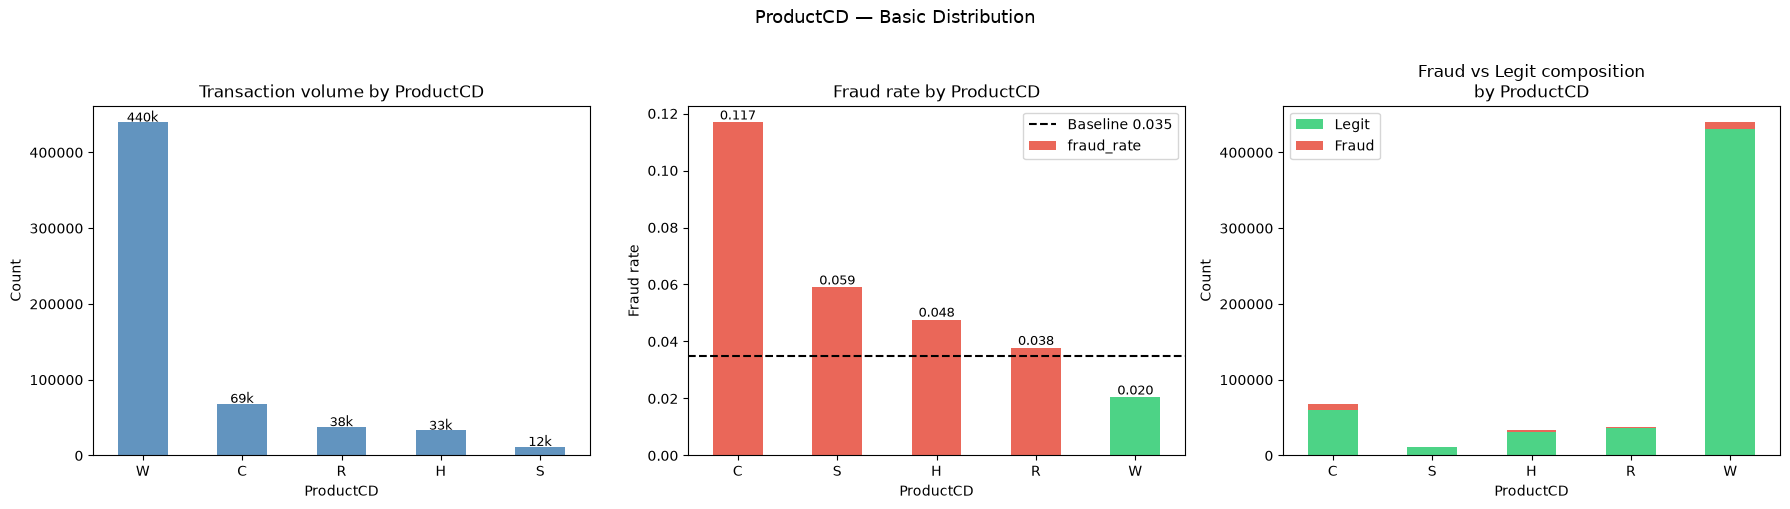

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Volume per product ────────────────────────────────────────────
prod_stats['count'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='steelblue', alpha=0.85
)
axes[0].set_title('Transaction volume by ProductCD')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('ProductCD')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f"{bar.get_height()/1000:.0f}k",
        ha='center', fontsize=9
    )

# ── Fraud rate per product ────────────────────────────────────────
colors = ['#e74c3c' if r > baseline else '#2ecc71'
          for r in prod_stats['fraud_rate'].sort_values(ascending=False)]
prod_stats['fraud_rate'].sort_values(ascending=False).plot.bar(
    ax=axes[1], color=colors, alpha=0.85
)
axes[1].axhline(baseline, color='black', linestyle='--',
                linewidth=1.5, label=f'Baseline {baseline:.3f}')
axes[1].set_title('Fraud rate by ProductCD')
axes[1].set_ylabel('Fraud rate')
axes[1].set_xlabel('ProductCD')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f"{bar.get_height():.3f}",
        ha='center', fontsize=9
    )

# ── Stacked bar: fraud vs legit composition ───────────────────────
stacked = prod_stats[['fraud_count','count']].copy()
stacked['legit_count'] = stacked['count'] - stacked['fraud_count']
stacked[['legit_count','fraud_count']].plot.bar(
    ax=axes[2], stacked=True,
    color=['#2ecc71','#e74c3c'], alpha=0.85
)
axes[2].set_title('Fraud vs Legit composition\nby ProductCD')
axes[2].set_ylabel('Count')
axes[2].legend(['Legit','Fraud'])
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('ProductCD — Basic Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('productcd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Is the fraud rate difference across products statistically significant?
ct = pd.crosstab(train['ProductCD'], train['isFraud'])
chi2, p, dof, expected = chi2_contingency(ct)

n        = ct.sum().sum()
cramers  = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Chi-square statistic : {chi2:.2f}")
print(f"p-value              : {p:.2e}")
print(f"Degrees of freedom   : {dof}")
print(f"Cramer's V           : {cramers:.4f}")
print(f"Significant          : {'YES' if p < 0.05 else 'NO'}")

# Cramer's V interpretation
if cramers < 0.1:
    strength = "weak"
elif cramers < 0.3:
    strength = "moderate"
else:
    strength = "strong"
print(f"Association strength : {strength}")

Chi-square statistic : 16742.17
p-value              : 0.00e+00
Degrees of freedom   : 4
Cramer's V           : 0.1684
Significant          : YES
Association strength : moderate


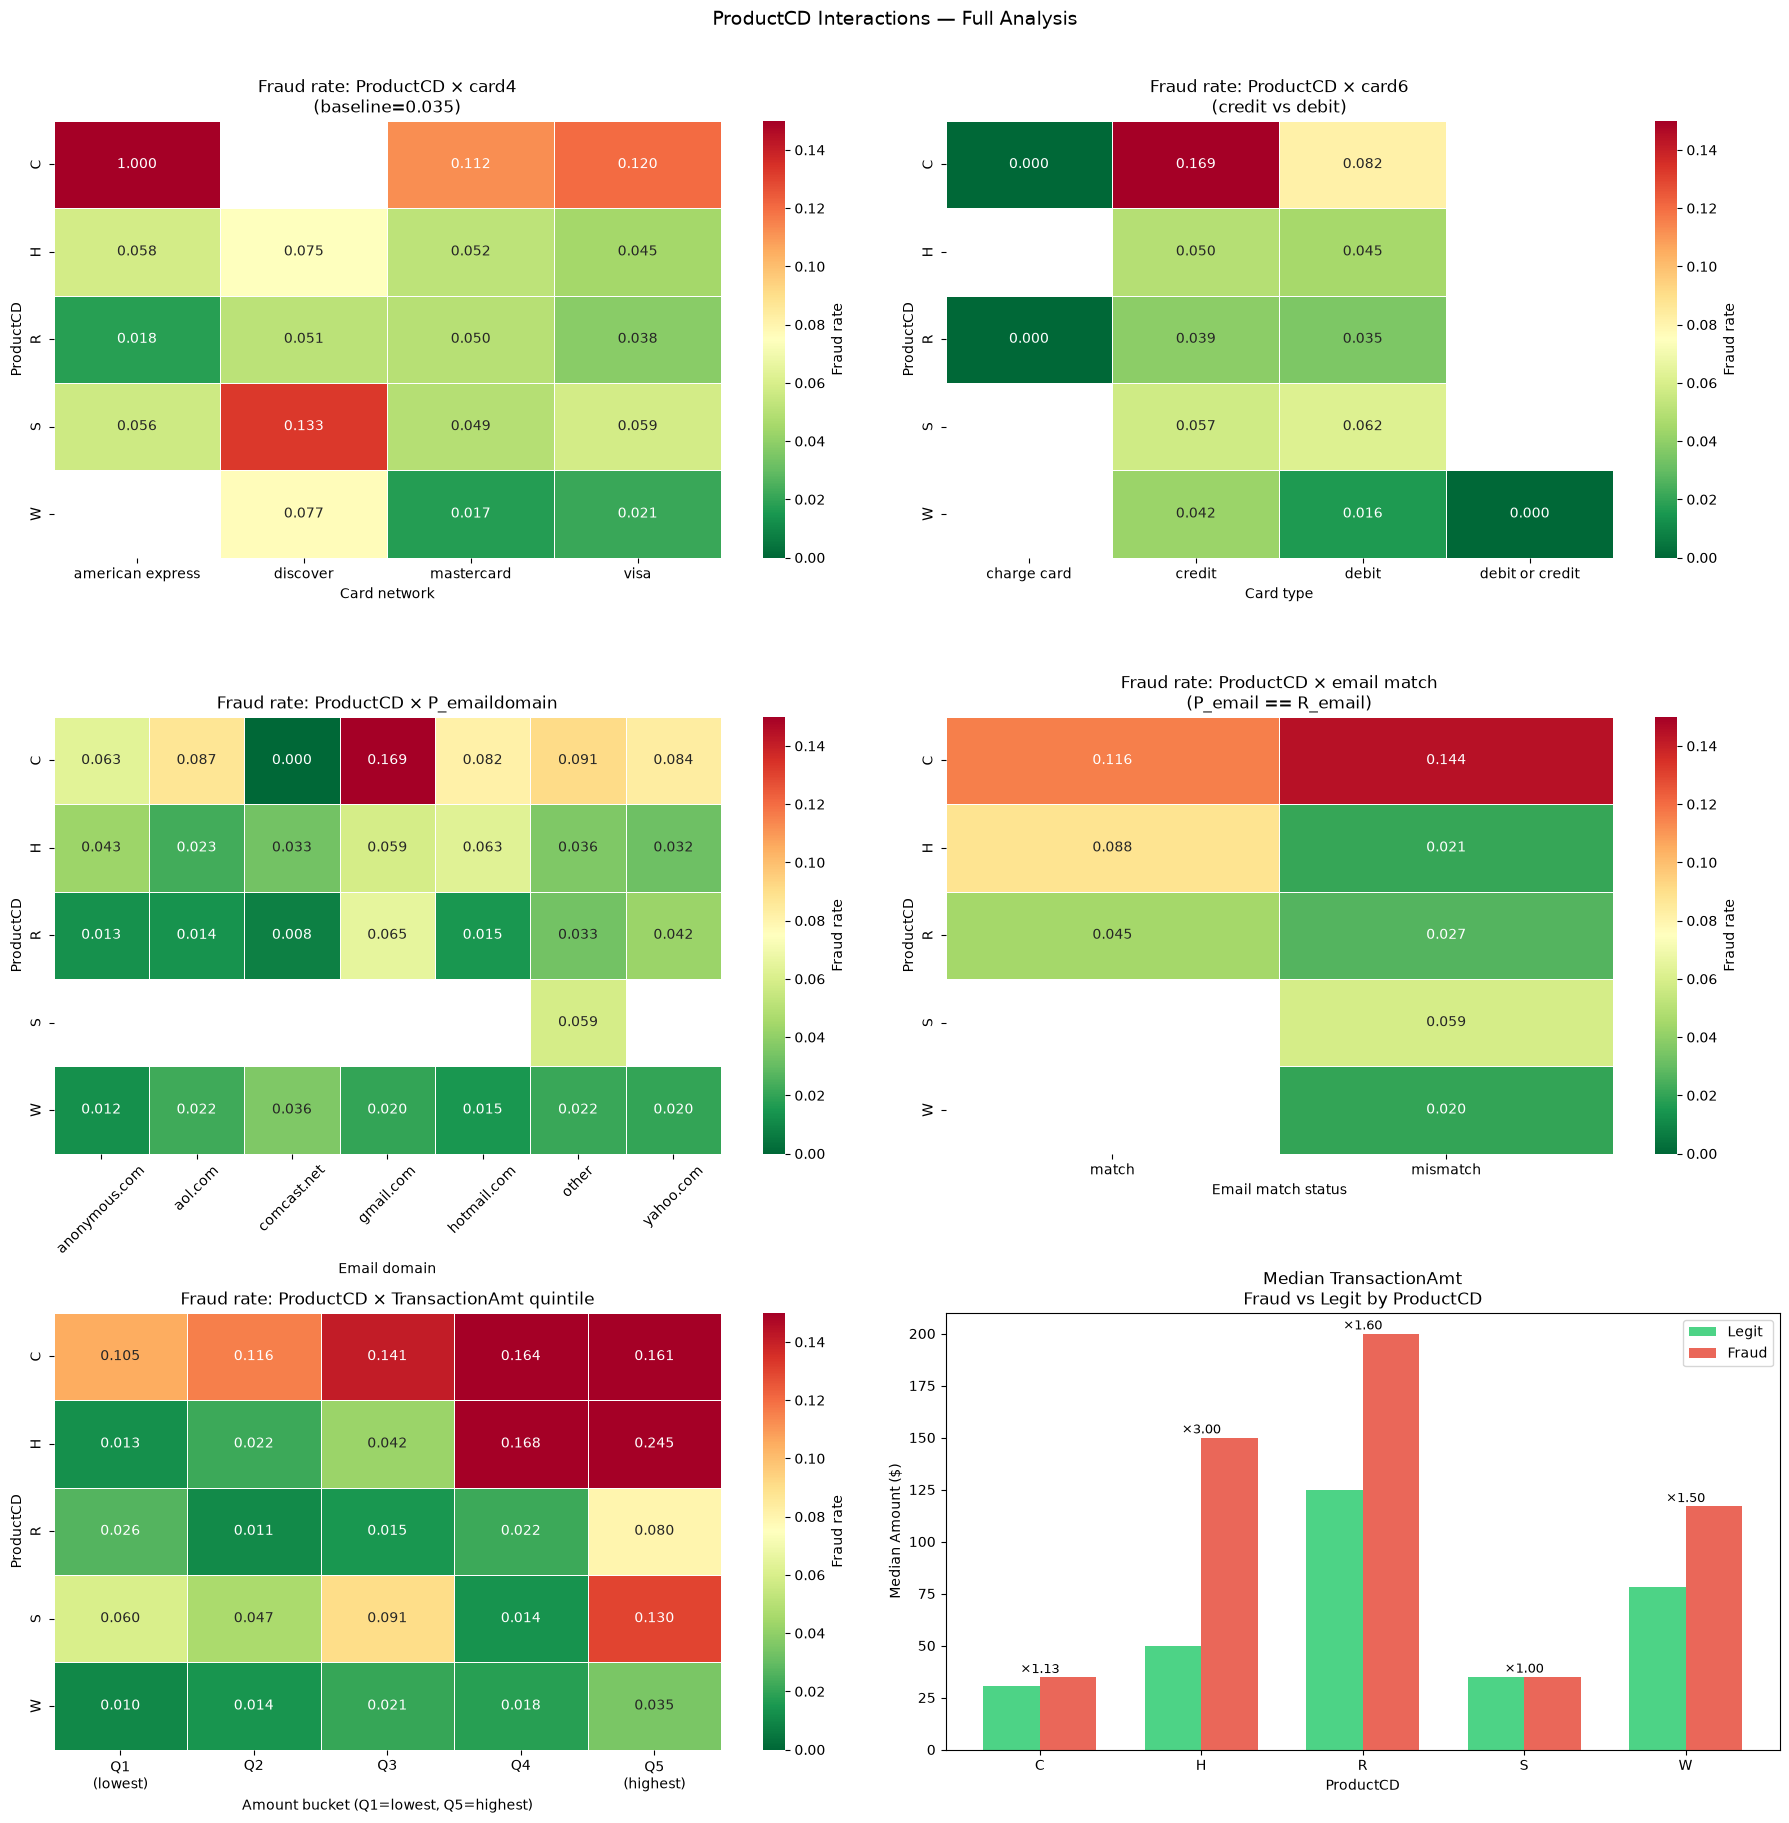


  KEY INTERACTION FINDINGS

ProductCD × card4
  Riskiest : C × american express → 1.000 (28.6× baseline)
  Safest   : W × mastercard → 0.017 (0.5× baseline)

ProductCD × card6
  Riskiest : C × credit → 0.169 (4.8× baseline)
  Safest   : C × charge card → 0.000 (0.0× baseline)

ProductCD × email
  Riskiest : C × gmail.com → 0.169 (4.8× baseline)
  Safest   : C × comcast.net → 0.000 (0.0× baseline)

ProductCD × amt_Q
  Riskiest : H × Q5
(highest) → 0.245 (7.0× baseline)
  Safest   : W × Q1
(lowest) → 0.010 (0.3× baseline)


In [51]:
# Checking interactions — ProductCD × card type, × email domain, × amount

baseline = train['isFraud'].mean()

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# ── 1. ProductCD × card4 (Visa / Mastercard / Discover / Amex) ───
interact_card4 = (
    train.groupby(['ProductCD', 'card4'], observed=True)['isFraud']
    .mean()
    .unstack()
)
sns.heatmap(
    interact_card4, annot=True, fmt='.3f',
    cmap='RdYlGn_r', ax=axes[0,0],
    linewidths=0.5, vmin=0, vmax=0.15,
    cbar_kws={'label': 'Fraud rate'}
)
axes[0,0].set_title(f'Fraud rate: ProductCD × card4\n(baseline={baseline:.3f})')
axes[0,0].set_xlabel('Card network')
axes[0,0].set_ylabel('ProductCD')

# ── 2. ProductCD × card6 (credit / debit) ────────────────────────
interact_card6 = (
    train.groupby(['ProductCD', 'card6'], observed=True)['isFraud']
    .mean()
    .unstack()
)
sns.heatmap(
    interact_card6, annot=True, fmt='.3f',
    cmap='RdYlGn_r', ax=axes[0,1],
    linewidths=0.5, vmin=0, vmax=0.15,
    cbar_kws={'label': 'Fraud rate'}
)
axes[0,1].set_title(f'Fraud rate: ProductCD × card6\n(credit vs debit)')
axes[0,1].set_xlabel('Card type')
axes[0,1].set_ylabel('ProductCD')

# ── 3. ProductCD × email domain (top 6 + other) ──────────────────
top_domains   = train['P_emaildomain'].value_counts().head(6).index.tolist()
train['email_grp'] = train['P_emaildomain'].where(
    train['P_emaildomain'].isin(top_domains), other='other'
).fillna('missing')

interact_email = (
    train.groupby(['ProductCD', 'email_grp'], observed=True)['isFraud']
    .mean()
    .unstack()
)
sns.heatmap(
    interact_email, annot=True, fmt='.3f',
    cmap='RdYlGn_r', ax=axes[1,0],
    linewidths=0.5, vmin=0, vmax=0.15,
    cbar_kws={'label': 'Fraud rate'}
)
axes[1,0].set_title('Fraud rate: ProductCD × P_emaildomain')
axes[1,0].set_xlabel('Email domain')
axes[1,0].set_ylabel('ProductCD')
axes[1,0].tick_params(axis='x', rotation=45)

# ── 4. ProductCD × email match (P_email == R_email) ──────────────
train['email_match'] = (
    train['P_emaildomain'] == train['R_emaildomain']
).map({True: 'match', False: 'mismatch'})
train['email_match'] = train['email_match'].fillna('one_missing')

interact_ematch = (
    train.groupby(['ProductCD', 'email_match'], observed=True)['isFraud']
    .mean()
    .unstack()
)
sns.heatmap(
    interact_ematch, annot=True, fmt='.3f',
    cmap='RdYlGn_r', ax=axes[1,1],
    linewidths=0.5, vmin=0, vmax=0.15,
    cbar_kws={'label': 'Fraud rate'}
)
axes[1,1].set_title('Fraud rate: ProductCD × email match\n(P_email == R_email)')
axes[1,1].set_xlabel('Email match status')
axes[1,1].set_ylabel('ProductCD')
axes[1,1].tick_params(axis='x', rotation=0)

# ── 5. ProductCD × TransactionAmt buckets ────────────────────────
train['amt_bucket'] = pd.qcut(
    train['TransactionAmt'],
    q=5,
    labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)']
)
interact_amt = (
    train.groupby(['ProductCD', 'amt_bucket'], observed=True)['isFraud']
    .mean()
    .unstack()
)
sns.heatmap(
    interact_amt, annot=True, fmt='.3f',
    cmap='RdYlGn_r', ax=axes[2,0],
    linewidths=0.5, vmin=0, vmax=0.15,
    cbar_kws={'label': 'Fraud rate'}
)
axes[2,0].set_title('Fraud rate: ProductCD × TransactionAmt quintile')
axes[2,0].set_xlabel('Amount bucket (Q1=lowest, Q5=highest)')
axes[2,0].set_ylabel('ProductCD')
axes[2,0].tick_params(axis='x', rotation=0)

# ── 6. Median amount per ProductCD × isFraud ─────────────────────
amt_stats = (
    train.groupby(['ProductCD', 'isFraud'], observed=True)['TransactionAmt']
    .agg(['median', 'mean', 'std'])
    .unstack()
)

# Plot median amount side by side
median_df = amt_stats['median'].rename(columns={0:'Legit', 1:'Fraud'})
x     = np.arange(len(median_df))
width = 0.35

axes[2,1].bar(x - width/2, median_df['Legit'],  width,
              color='#2ecc71', alpha=0.85, label='Legit')
axes[2,1].bar(x + width/2, median_df['Fraud'], width,
              color='#e74c3c', alpha=0.85, label='Fraud')
axes[2,1].set_xticks(x)
axes[2,1].set_xticklabels(median_df.index)
axes[2,1].set_title('Median TransactionAmt\nFraud vs Legit by ProductCD')
axes[2,1].set_ylabel('Median Amount ($)')
axes[2,1].set_xlabel('ProductCD')
axes[2,1].legend()

# Annotate fraud/legit ratio above each pair
for i, prod in enumerate(median_df.index):
    ratio = median_df.loc[prod, 'Fraud'] / (median_df.loc[prod, 'Legit'] + 1e-6)
    axes[2,1].text(
        i, max(median_df.loc[prod, 'Fraud'], median_df.loc[prod, 'Legit']) + 2,
        f'×{ratio:.2f}',
        ha='center', fontsize=9, color='black'
    )

plt.suptitle('ProductCD Interactions — Full Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Cleanup temp columns ──────────────────────────────────────────
train.drop(
    columns=['email_grp', 'email_match', 'amt_bucket'],
    inplace=True, errors='ignore'
)

# ── Summary table ─────────────────────────────────────────────────
print("\n" + "="*60)
print("  KEY INTERACTION FINDINGS")
print("="*60)

# Highest risk combination across all interactions
for name, df_int in [
    ('ProductCD × card4',    interact_card4),
    ('ProductCD × card6',    interact_card6),
    ('ProductCD × email',    interact_email),
    ('ProductCD × amt_Q',    interact_amt),
]:
    flat   = df_int.stack().reset_index()
    flat.columns = ['ProductCD', 'category', 'fraud_rate']
    top    = flat.loc[flat['fraud_rate'].idxmax()]
    bottom = flat.loc[flat['fraud_rate'].idxmin()]
    print(f"\n{name}")
    print(f"  Riskiest : {top['ProductCD']} × {top['category']}"
          f" → {top['fraud_rate']:.3f} "
          f"({top['fraud_rate']/baseline:.1f}× baseline)")
    print(f"  Safest   : {bottom['ProductCD']} × {bottom['category']}"
          f" → {bottom['fraud_rate']:.3f} "
          f"({bottom['fraud_rate']/baseline:.1f}× baseline)")

## V-Feature Investigation

In [52]:
v_cols    = [c for c in train.columns if c.startswith('V')]
print(f"V columns found : {len(v_cols)}")
print(f"Baseline fraud  : {baseline:.4%}")

V columns found : 339
Baseline fraud  : 3.4990%


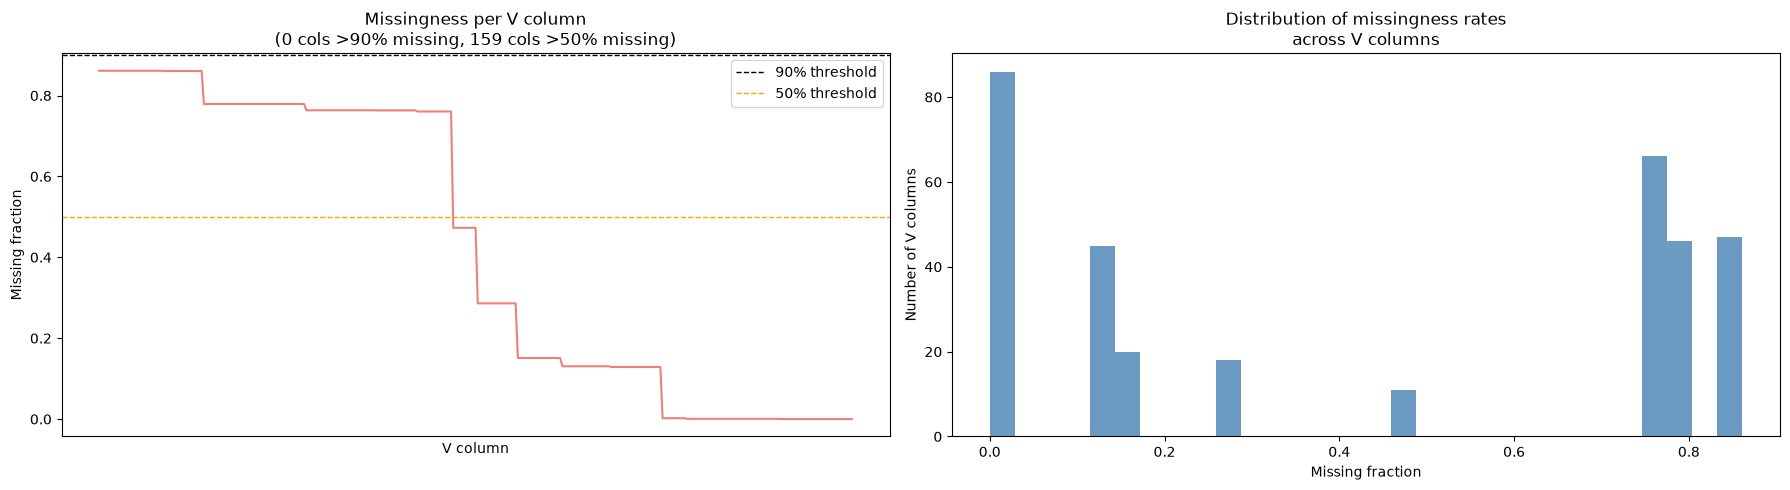


Missingness summary:
  Zero missing          : 0
  0–50% missing         : 180
  50–90% missing        : 159
  >90% missing          : 0


In [53]:
#1 — Missingness overview

# Missingness is the most important structural property of V features
miss_pct = train[v_cols].isnull().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart of missingness per V column
miss_pct.plot(ax=axes[0], color='#e74c3c', alpha=0.7)
axes[0].axhline(0.90, color='black', linestyle='--',
                linewidth=1, label='90% threshold')
axes[0].axhline(0.50, color='orange', linestyle='--',
                linewidth=1, label='50% threshold')
axes[0].set_title(f'Missingness per V column\n'
                  f'({(miss_pct > 0.9).sum()} cols >90% missing, '
                  f'{(miss_pct > 0.5).sum()} cols >50% missing)')
axes[0].set_xlabel('V column')
axes[0].set_ylabel('Missing fraction')
axes[0].set_xticks([])
axes[0].legend()

# Missingness distribution histogram 
miss_pct.plot.hist(bins=30, ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Distribution of missingness rates\nacross V columns')
axes[1].set_xlabel('Missing fraction')
axes[1].set_ylabel('Number of V columns')

plt.tight_layout()
plt.savefig('v_missingness_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\nMissingness summary:")
print(f"  Zero missing          : {(miss_pct == 0).sum()}")
print(f"  0–50% missing         : {((miss_pct > 0) & (miss_pct <= 0.5)).sum()}")
print(f"  50–90% missing        : {((miss_pct > 0.5) & (miss_pct <= 0.9)).sum()}")
print(f"  >90% missing          : {(miss_pct > 0.9).sum()}")

In [54]:
#2 — Missingness pattern grouping 

# V features that share identical missingness patterns

miss_patterns = train[v_cols].isnull().T.apply(
    lambda r: r.values.tobytes(), axis=1
)
groups = {}
for col, pat in miss_patterns.items():
    groups.setdefault(pat, []).append(col)

print(f"Distinct missingness groups : {len(groups)}")
print(f"\nGroup breakdown:")
for i, (pat, cols) in enumerate(groups.items()):
    sparsity = train[cols].isnull().mean().mean()
    print(f"  Group {i+1:2d} : {len(cols):3d} cols | "
          f"avg missingness {sparsity:.1%} | "
          f"cols: {cols[:4]}{'...' if len(cols)>4 else ''}")

Distinct missingness groups : 15

Group breakdown:
  Group  1 :  11 cols | avg missingness 47.3% | cols: ['V1', 'V2', 'V3', 'V4']...
  Group  2 :  23 cols | avg missingness 12.9% | cols: ['V12', 'V13', 'V14', 'V15']...
  Group  3 :  18 cols | avg missingness 28.6% | cols: ['V35', 'V36', 'V37', 'V38']...
  Group  4 :  22 cols | avg missingness 13.1% | cols: ['V53', 'V54', 'V55', 'V56']...
  Group  5 :  20 cols | avg missingness 15.1% | cols: ['V75', 'V76', 'V77', 'V78']...
  Group  6 :  43 cols | avg missingness 0.1% | cols: ['V95', 'V96', 'V97', 'V98']...
  Group  7 :  18 cols | avg missingness 86.1% | cols: ['V138', 'V139', 'V140', 'V141']...
  Group  8 :  11 cols | avg missingness 86.1% | cols: ['V143', 'V144', 'V145', 'V150']...
  Group  9 :  31 cols | avg missingness 76.4% | cols: ['V167', 'V168', 'V172', 'V173']...
  Group 10 :  19 cols | avg missingness 76.3% | cols: ['V169', 'V170', 'V171', 'V174']...
  Group 11 :  46 cols | avg missingness 77.9% | cols: ['V217', 'V218', 'V219',

Total V columns : 339
Baseline fraud  : 3.4990%

Computing AUC per V column...

V features computed  : 339
AUC > 0.60           : 117
AUC > 0.55           : 195
AUC > 0.52           : 258

Top 20 V features by AUC:
V258    0.745289
V218    0.737746
V219    0.734395
V264    0.730745
V257    0.727911
V265    0.726588
V217    0.716265
V232    0.712599
V229    0.712272
V274    0.710638
V263    0.709277
V246    0.707070
V233    0.704146
V230    0.703272
V52     0.702535
V275    0.702000
V51     0.698208
V201    0.696589
V243    0.694628
V199    0.693574


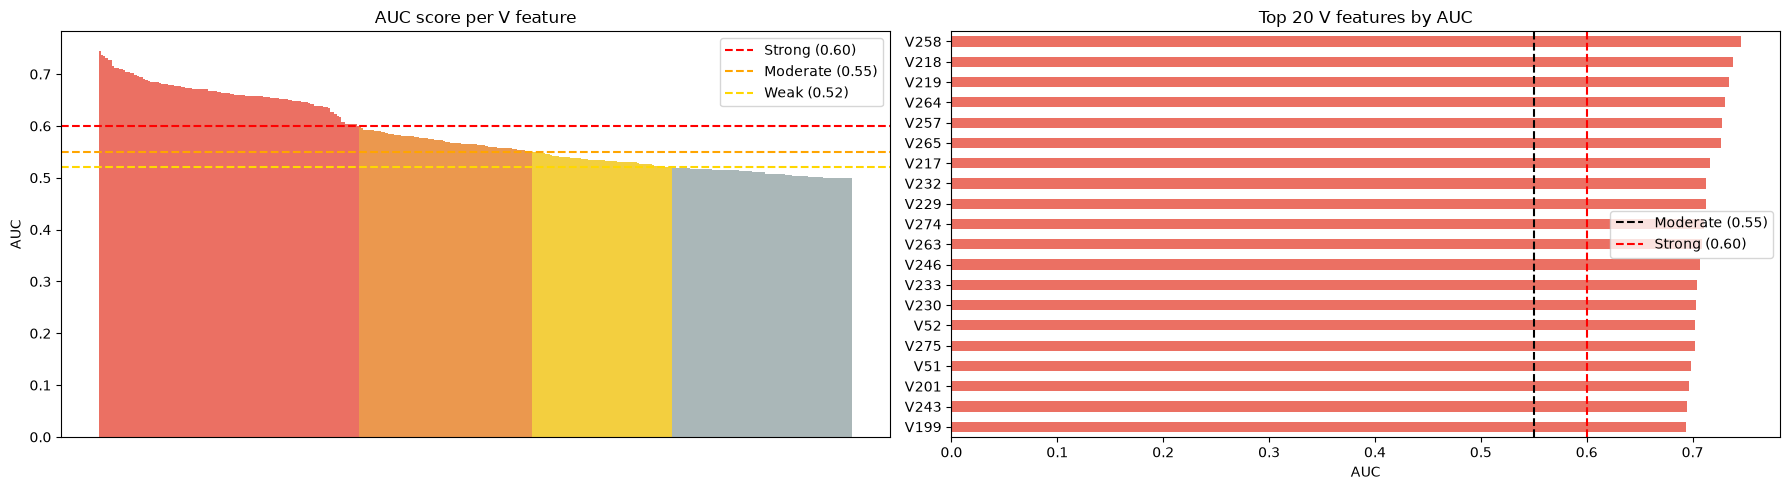

In [55]:
v_cols   = [c for c in train.columns if c.startswith('V')]
baseline = train['isFraud'].mean()

print(f"Total V columns : {len(v_cols)}")
print(f"Baseline fraud  : {baseline:.4%}")

# ── AUC per V column ──────────────────────────────────────────────
print("\nComputing AUC per V column...")
auc_scores = {}

for col in v_cols:
    clean = train[[col, 'isFraud']].dropna()
    if len(clean) < 1000 or clean[col].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(clean['isFraud'], clean[col])
        auc_scores[col] = max(auc, 1 - auc)
    except Exception as e:
        print(f"  Skipped {col}: {e}")
        continue

auc_series = pd.Series(auc_scores).sort_values(ascending=False)

print(f"\nV features computed  : {len(auc_scores)}")
print(f"AUC > 0.60           : {(auc_series > 0.60).sum()}")
print(f"AUC > 0.55           : {(auc_series > 0.55).sum()}")
print(f"AUC > 0.52           : {(auc_series > 0.52).sum()}")
print(f"\nTop 20 V features by AUC:")
print(auc_series.head(20).to_string())

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

colors = ['#e74c3c' if a > 0.60 else
          '#e67e22' if a > 0.55 else
          '#f1c40f' if a > 0.52 else
          '#95a5a6' for a in auc_series.values]

axes[0].bar(range(len(auc_series)), auc_series.values,
            color=colors, alpha=0.8, width=1.0)
axes[0].axhline(0.60, color='red',    linestyle='--', label='Strong (0.60)')
axes[0].axhline(0.55, color='orange', linestyle='--', label='Moderate (0.55)')
axes[0].axhline(0.52, color='gold',   linestyle='--', label='Weak (0.52)')
axes[0].set_title('AUC score per V feature')
axes[0].set_xticks([])
axes[0].set_ylabel('AUC')
axes[0].legend()

top_n = min(20, len(auc_series))
auc_series.head(top_n).sort_values().plot.barh(
    ax=axes[1], color='#e74c3c', alpha=0.8
)
axes[1].axvline(0.55, color='black', linestyle='--', label='Moderate (0.55)')
axes[1].axvline(0.60, color='red',   linestyle='--', label='Strong (0.60)')
axes[1].set_title(f'Top {top_n} V features by AUC')
axes[1].set_xlabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('v_auc_scores.png', dpi=150, bbox_inches='tight')
plt.show()

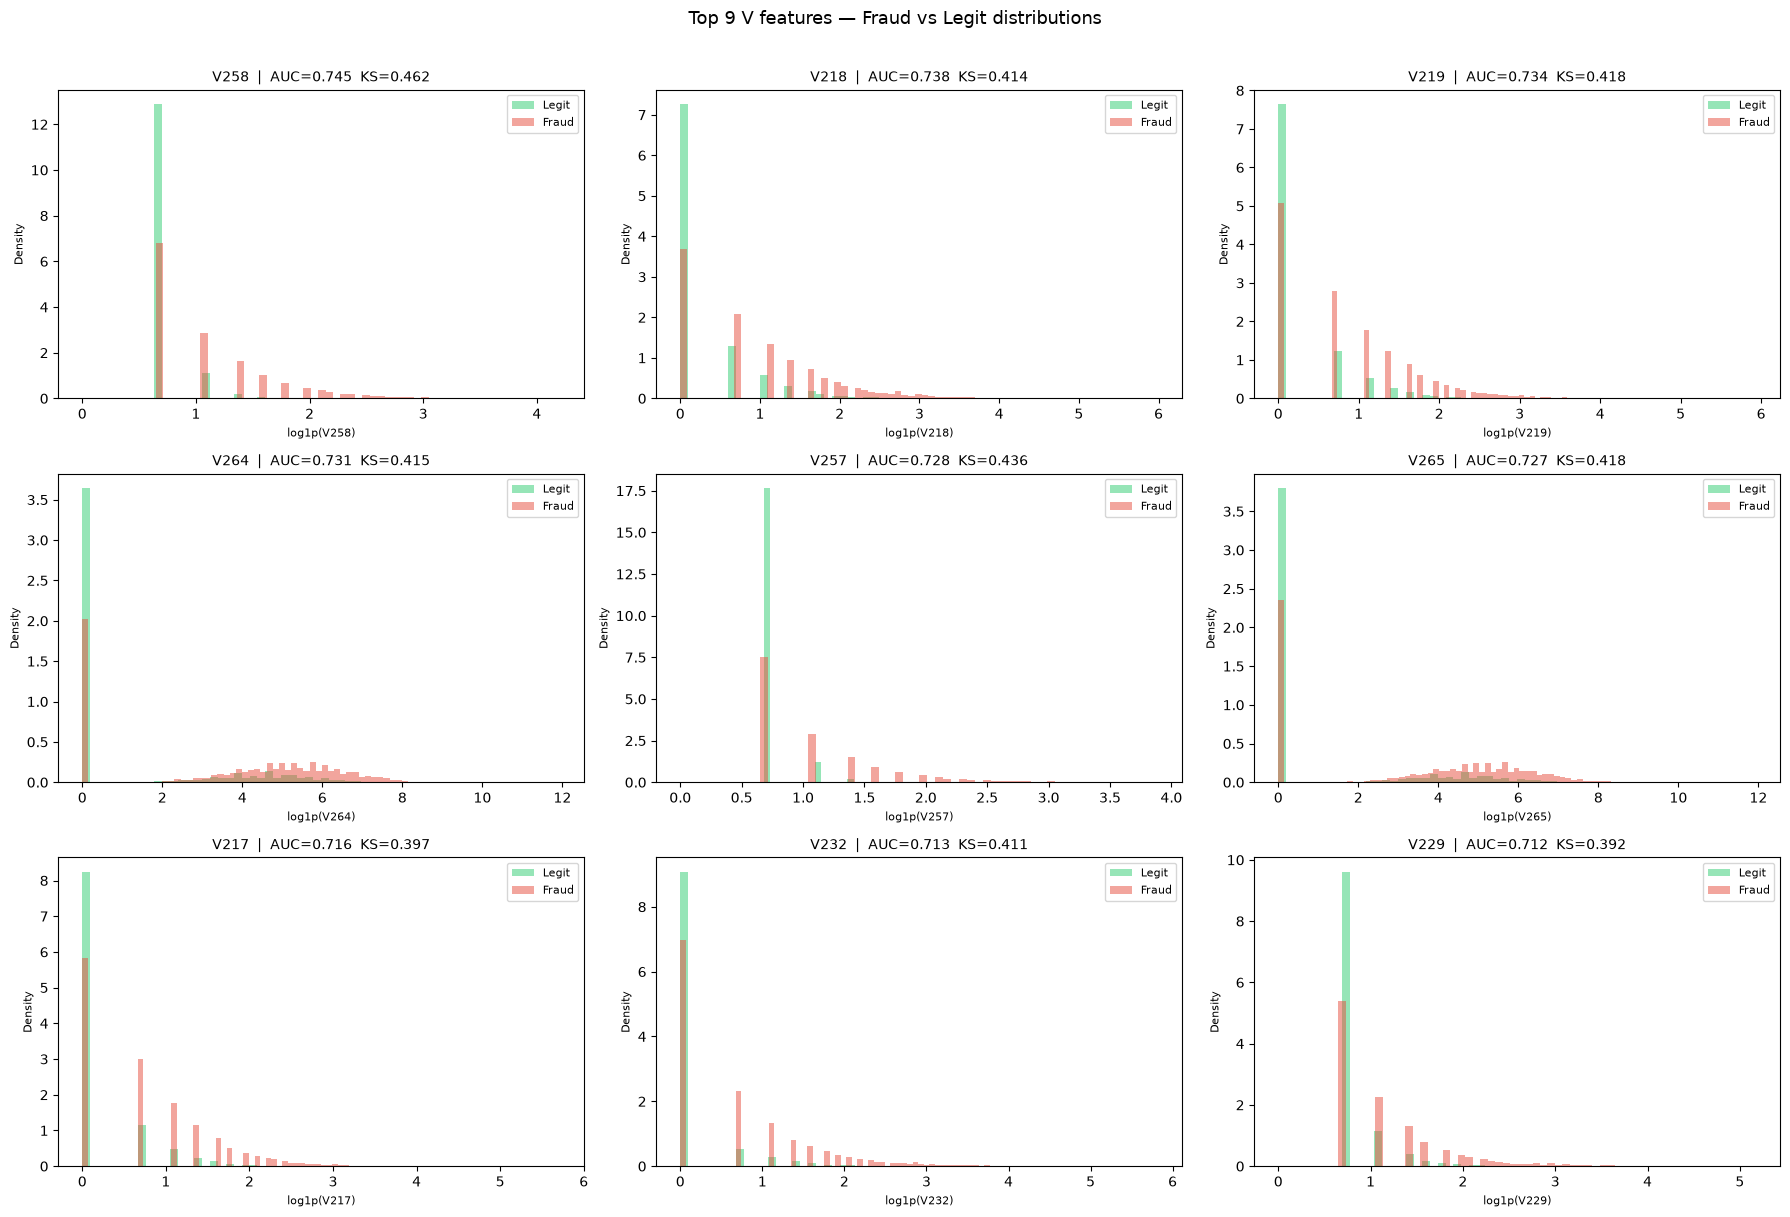

In [56]:
# EDA 4 — Distribution analysis of top V features

top_v = auc_series.head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), top_v):
    f_vals = train.loc[train['isFraud']==1, col].dropna()
    l_vals = train.loc[train['isFraud']==0, col].dropna()

    # Use log scale if heavily skewed
    skewness = train[col].dropna().skew()
    if abs(skewness) > 2:
        f_vals = np.log1p(f_vals.clip(lower=0))
        l_vals = np.log1p(l_vals.clip(lower=0))
        xlabel = f'log1p({col})'
    else:
        xlabel = col

    ax.hist(l_vals, bins=60, alpha=0.5, color='#2ecc71',
            label='Legit', density=True)
    ax.hist(f_vals, bins=60, alpha=0.5, color='#e74c3c',
            label='Fraud', density=True)

    # KS statistic
    ks_stat, _ = stats.ks_2samp(f_vals, l_vals)

    ax.set_title(f'{col}  |  AUC={auc_scores[col]:.3f}  '
                 f'KS={ks_stat:.3f}',
                 fontsize=10)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Top 9 V features — Fraud vs Legit distributions',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('v_top_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Running KS + Mann-Whitney tests on all V features...

Significant by KS  (p<0.05): 307
Significant by MW  (p<0.05): 331

Top 20 V features by KS statistic:
feature  ks_stat  mw_normalised  fraud_median  legit_median    auc
   V258   0.4621         0.7453      2.000000           1.0 0.7453
   V257   0.4360         0.7279      2.000000           1.0 0.7279
   V265   0.4179         0.7266     62.353401           0.0 0.7266
   V219   0.4178         0.7344      1.000000           0.0 0.7344
   V264   0.4151         0.7307     78.924500           0.0 0.7307
   V218   0.4140         0.7377      2.000000           0.0 0.7377
   V274   0.4107         0.7106     20.558701           0.0 0.7106
   V232   0.4107         0.7126      1.000000           0.0 0.7126
   V246   0.4032         0.7071      1.000000           1.0 0.7071
   V263   0.3974         0.7093     44.976200           0.0 0.7093
   V217   0.3971         0.7163      1.000000           0.0 0.7163
   V275   0.3962         0.7020     10.0

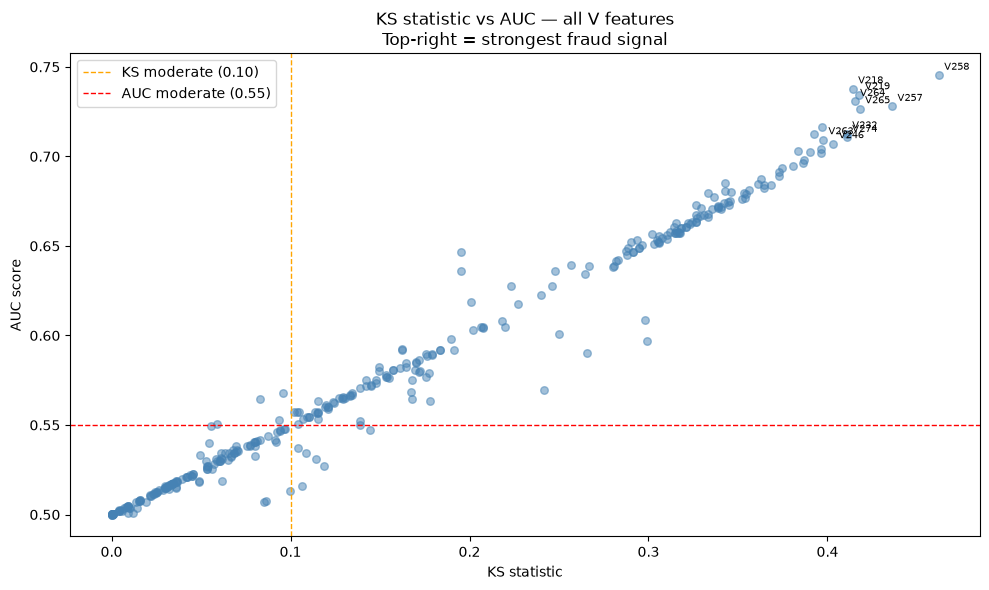

In [57]:
# EDA 5 — KS test + Mann-Whitney across all V features

print("Running KS + Mann-Whitney tests on all V features...")

test_results = []
fraud = train[train['isFraud'] == 1]
legit = train[train['isFraud'] == 0]

for col in v_cols:
    f_vals = fraud[col].dropna()
    l_vals = legit[col].dropna()

    if len(f_vals) < 100 or len(l_vals) < 100:
        continue

    ks_stat, ks_p   = stats.ks_2samp(f_vals, l_vals)
    mw_stat, mw_p   = stats.mannwhitneyu(
        f_vals, l_vals, alternative='two-sided'
    )
    mw_norm = mw_stat / (len(f_vals) * len(l_vals))
    mw_norm = max(mw_norm, 1 - mw_norm)

    test_results.append({
        'feature'       : col,
        'ks_stat'       : round(ks_stat, 4),
        'ks_pvalue'     : round(ks_p, 6),
        'mw_normalised' : round(mw_norm, 4),
        'mw_pvalue'     : round(mw_p, 6),
        'fraud_median'  : round(f_vals.median(), 4),
        'legit_median'  : round(l_vals.median(), 4),
        'auc'           : round(auc_scores.get(col, 0.5), 4),
    })

tests_df = (pd.DataFrame(test_results)
              .sort_values('ks_stat', ascending=False))

print(f"\nSignificant by KS  (p<0.05): {(tests_df['ks_pvalue']  < 0.05).sum()}")
print(f"Significant by MW  (p<0.05): {(tests_df['mw_pvalue']   < 0.05).sum()}")
print(f"\nTop 20 V features by KS statistic:")
print(tests_df.head(20)[['feature','ks_stat','mw_normalised',
                          'fraud_median','legit_median','auc']].to_string(index=False))

# ── KS vs AUC scatter ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tests_df['ks_stat'], tests_df['auc'],
           alpha=0.5, color='steelblue', s=30)
ax.axvline(0.10, color='orange', linestyle='--',
           linewidth=1, label='KS moderate (0.10)')
ax.axhline(0.55, color='red',    linestyle='--',
           linewidth=1, label='AUC moderate (0.55)')
ax.set_xlabel('KS statistic')
ax.set_ylabel('AUC score')
ax.set_title('KS statistic vs AUC — all V features\n'
             'Top-right = strongest fraud signal')
ax.legend()

# Label top 10
for _, row in tests_df.head(10).iterrows():
    ax.annotate(row['feature'],
                (row['ks_stat'], row['auc']),
                fontsize=7, xytext=(4, 4),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('v_ks_vs_auc.png', dpi=150, bbox_inches='tight')
plt.show()

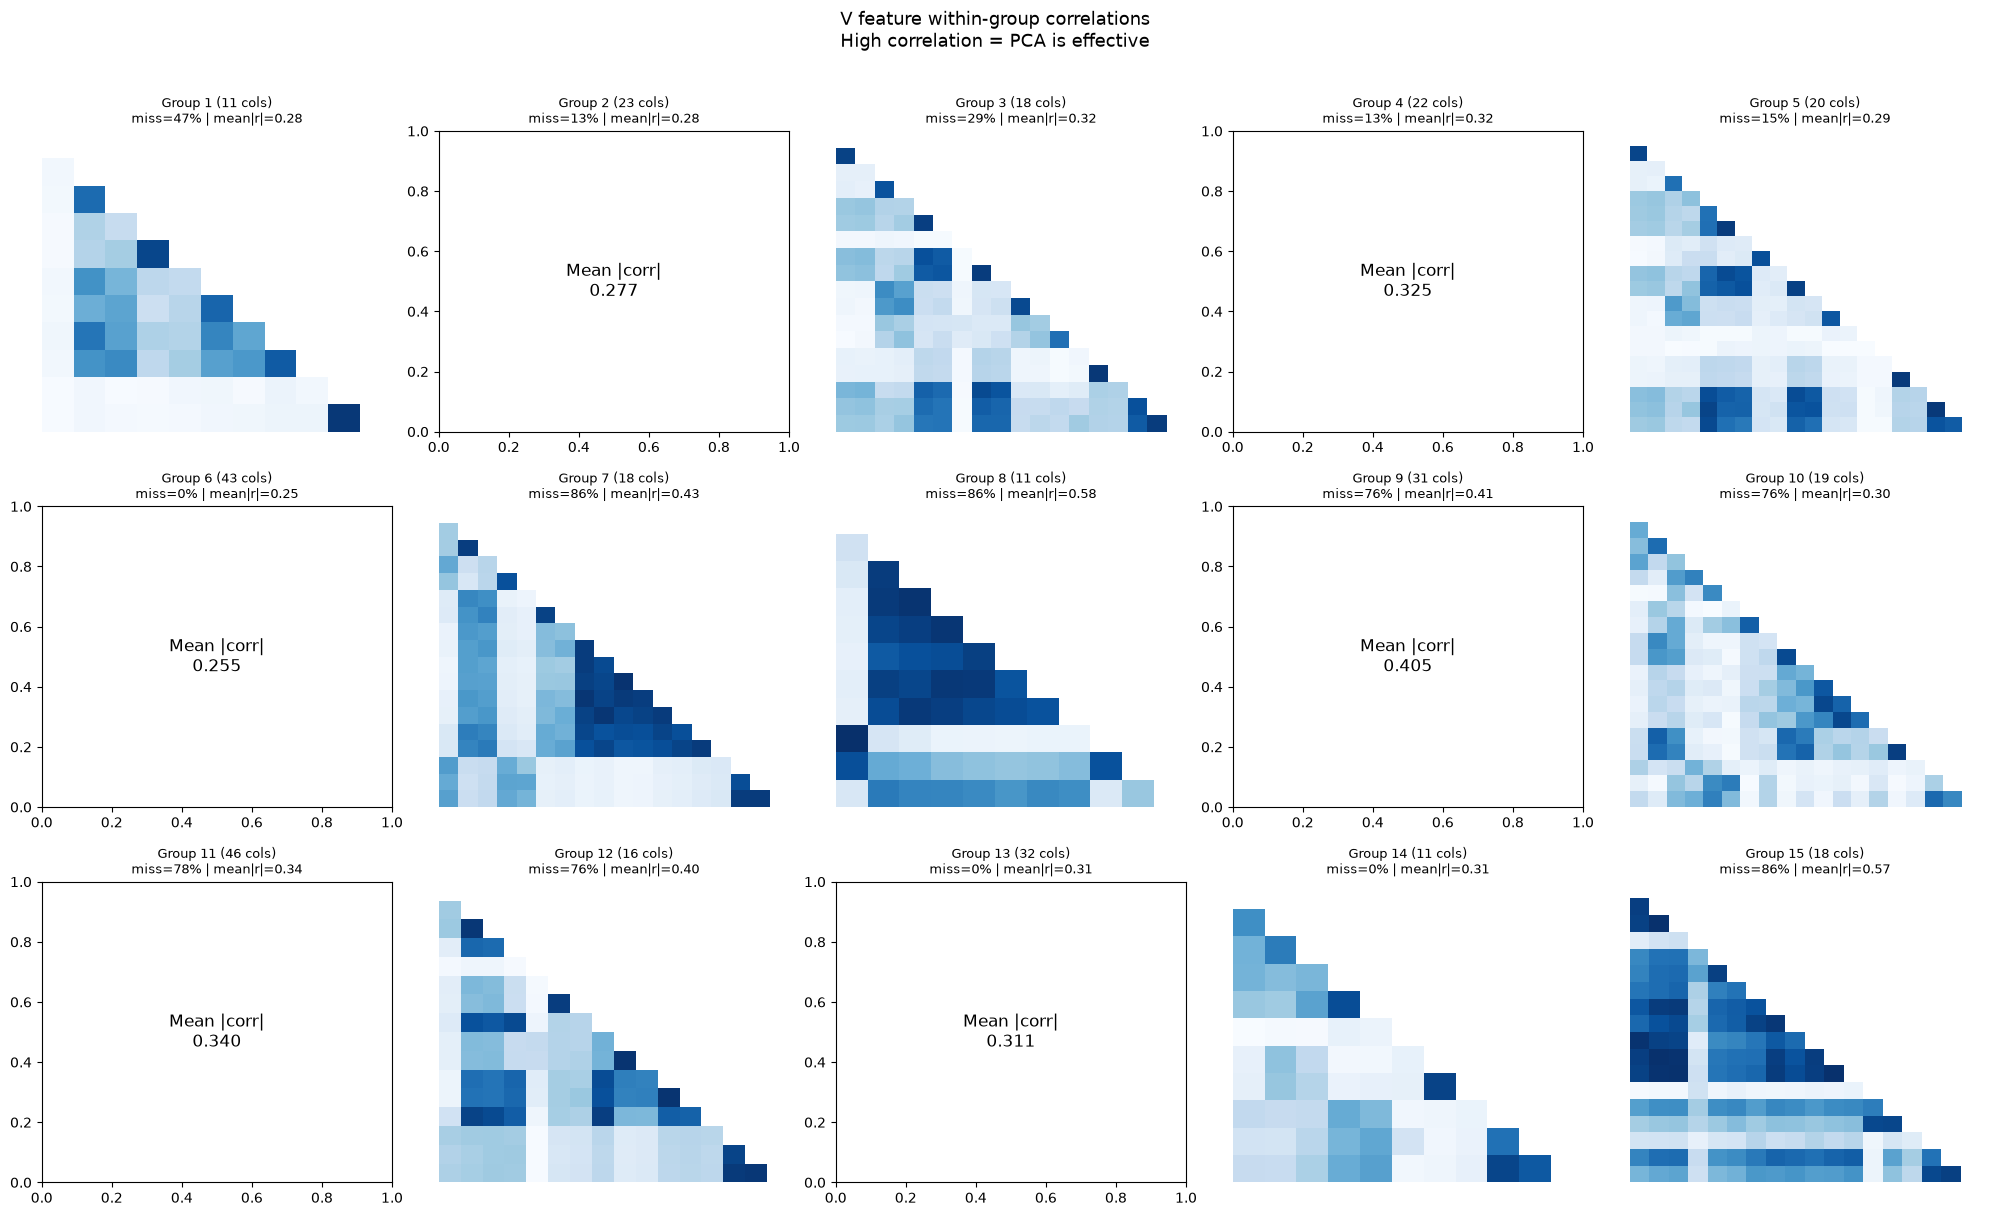

In [58]:
# EDA 6 — Correlation within groups 

# Within each missingness group, how correlated are the V features?
# High correlation = PCA will work well
# Low correlation = features are independent, PCA loses signal

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()

for i, (pat, group_cols) in enumerate(groups.items()):
    if i >= 15 or len(group_cols) < 2:
        continue

    ax = axes_flat[i]

    # Correlation matrix for this group
    corr = train[group_cols].corr().abs()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Only show heatmap if manageable size
    if len(group_cols) <= 20:
        sns.heatmap(
            corr, mask=mask, ax=ax,
            cmap='Blues', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar=False
        )
    else:
        # For large groups just show mean correlation
        ax.text(0.5, 0.5,
                f'Mean |corr|\n{corr.values[~np.eye(len(corr),dtype=bool)].mean():.3f}',
                ha='center', va='center',
                transform=ax.transAxes, fontsize=12)

    sparsity = train[group_cols].isnull().mean().mean()
    mean_corr = corr.values[~np.eye(len(corr), dtype=bool)].mean()
    ax.set_title(f'Group {i+1} ({len(group_cols)} cols)\n'
                 f'miss={sparsity:.0%} | mean|r|={mean_corr:.2f}',
                 fontsize=9)

plt.suptitle('V feature within-group correlations\n'
             'High correlation = PCA is effective',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('v_group_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


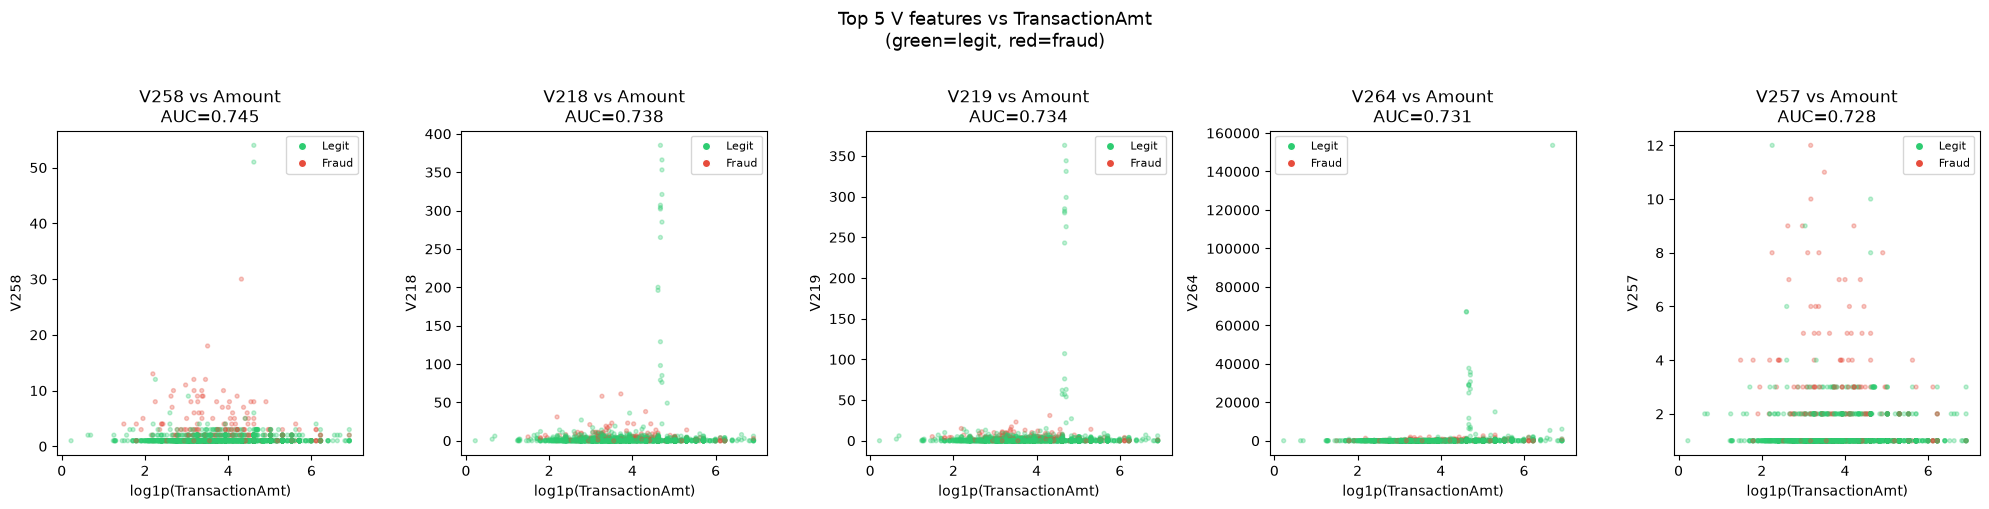

In [59]:
# Do top V features interact with transaction amount?
top_5_v = auc_series.head(5).index.tolist()

fig, axes = plt.subplots(1, len(top_5_v), figsize=(20, 5))

for ax, col in zip(axes, top_5_v):
    # Scatter: V feature vs log amount, coloured by fraud
    sample = train[[col, 'TransactionAmt', 'isFraud']].dropna().sample(
        min(3000, train[col].notnull().sum()), random_state=42
    )
    colors_scatter = sample['isFraud'].map({0:'#2ecc71', 1:'#e74c3c'})
    ax.scatter(
        np.log1p(sample['TransactionAmt']),
        sample[col],
        c=colors_scatter,
        alpha=0.3, s=8
    )
    ax.set_xlabel('log1p(TransactionAmt)')
    ax.set_ylabel(col)
    ax.set_title(f'{col} vs Amount\nAUC={auc_scores[col]:.3f}')

    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='#2ecc71', label='Legit', markersize=6),
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='#e74c3c', label='Fraud', markersize=6),
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.suptitle('Top 5 V features vs TransactionAmt\n'
             '(green=legit, red=fraud)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('v_vs_amount.png', dpi=150, bbox_inches='tight')
plt.show()


V feature group signal summary:
group  n_cols  sparsity  mean_auc  max_auc  n_strong top_feature
   G3      18     0.286    0.6358   0.7025        15         V52
  G11      46     0.779    0.6223   0.7453        21        V258
   G5      20     0.151    0.6174   0.6822        12         V94
   G7      18     0.861    0.6095   0.6769        12        V140
   G9      31     0.764    0.6053   0.6936        16        V199
   G4      22     0.131    0.6026   0.6708        12         V74
   G2      23     0.129    0.5986   0.6764        12         V34
  G10      19     0.763    0.5791   0.6966         6        V201
  G13      32     0.000    0.5569   0.6626         5        V303
   G8      11     0.861    0.5507   0.6006         1        V150
  G14      11     0.002    0.5488   0.6464         2        V283
  G12      16     0.761    0.5470   0.6084         1        V222
   G1      11     0.473    0.5403   0.6390         2         V10
  G15      18     0.861    0.5355   0.5751         0     

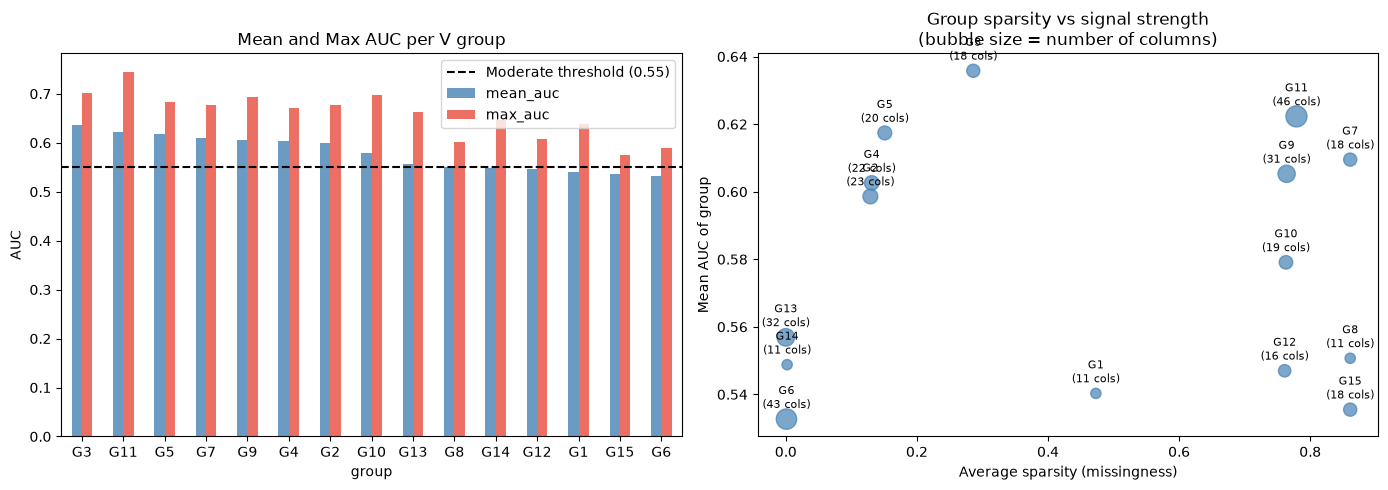

In [60]:
# Which missingness groups contain the most useful V features?

group_summary = []
for i, (pat, group_cols) in enumerate(groups.items()):
    group_aucs = [auc_scores.get(c, 0.5) for c in group_cols
                  if c in auc_scores]
    if not group_aucs:
        continue

    sparsity = train[group_cols].isnull().mean().mean()
    group_summary.append({
        'group'        : f'G{i+1}',
        'n_cols'       : len(group_cols),
        'sparsity'     : round(sparsity, 3),
        'mean_auc'     : round(np.mean(group_aucs), 4),
        'max_auc'      : round(np.max(group_aucs),  4),
        'n_strong'     : sum(a > 0.60 for a in group_aucs),
        'top_feature'  : group_cols[np.argmax(group_aucs)]
    })

group_df = pd.DataFrame(group_summary).sort_values('mean_auc', ascending=False)
print("\nV feature group signal summary:")
print(group_df.to_string(index=False))

# ── Visual summary ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_df.plot.bar(x='group', y=['mean_auc','max_auc'],
                  ax=axes[0], color=['steelblue','#e74c3c'],
                  alpha=0.8)
axes[0].axhline(0.55, color='black', linestyle='--',
                label='Moderate threshold (0.55)')
axes[0].set_title('Mean and Max AUC per V group')
axes[0].set_ylabel('AUC')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

axes[1].scatter(group_df['sparsity'], group_df['mean_auc'],
                s=group_df['n_cols']*5,
                color='steelblue', alpha=0.7)
for _, row in group_df.iterrows():
    axes[1].annotate(
        f"{row['group']}\n({row['n_cols']} cols)",
        (row['sparsity'], row['mean_auc']),
        fontsize=8, ha='center', xytext=(0, 8),
        textcoords='offset points'
    )
axes[1].set_xlabel('Average sparsity (missingness)')
axes[1].set_ylabel('Mean AUC of group')
axes[1].set_title('Group sparsity vs signal strength\n'
                  '(bubble size = number of columns)')

plt.tight_layout()
plt.savefig('v_group_signal.png', dpi=150, bbox_inches='tight')
plt.show()